# Quantum Gates — Interactive Companion Notebook (with Visualizations, Circuits & Measurements)

### Based on: QC_notes_gates.pdf — Chapter 3 (Quantum Gates) and selected parts of Chapter 4

This notebook is a hands-on, Qiskit-based companion to the lecture-note chapter on **Quantum Gates**. It follows the same structure and equation numbering as the PDF. Every section now includes:

- A **circuit diagram** (drawn with the matplotlib circuit drawer)
- **Bloch-sphere** and/or **state-city / Q-sphere** visualizations
- Explicit **measurements**, executed on a simulator, shown as **histograms**

Style and structure are inspired by:
- IBM Qiskit Community Tutorials (Coding With Qiskit, ep.4 — Gates)
- Qiskit Community Tutorials — Teach Me Quantum 2018 / Teach Me Qiskit 2018
- Qiskit/qiskit-tutorials (official GitHub tutorials)
- IBM Quantum Learning — Basics of Quantum Information course

Install requirements:

    pip install qiskit qiskit-aer matplotlib numpy pylatexenc

In [1]:
pip install qiskit qiskit-aer matplotlib numpy pylatexenc

Note: you may need to restart the kernel to use updated packages.


## References used to build this notebook

1. QC_notes_gates.pdf — Chapter 3 'Quantum Gates' and Chapter 4 excerpt (primary source)
2. Qiskit Community Tutorials — https://github.com/qiskit-community/qiskit-community-tutorials
3. Coding With Qiskit, Episode 4: Gates — .../Coding_With_Qiskit/ep4_Gates.ipynb
4. Teach Me Quantum 2018 — Basic Intro to QC — .../awards/teach_me_quantum_2018
5. Teach Me Qiskit 2018 — .../awards/teach_me_qiskit_2018
6. Qiskit/qiskit-tutorials — https://github.com/Qiskit/qiskit-tutorials
7. IBM Quantum Learning — https://quantum.cloud.ibm.com/learning/en
8. IBM Quantum Learning — Basics of Quantum Information course

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator, DensityMatrix, state_fidelity
from qiskit.visualization import (plot_bloch_multivector, plot_bloch_vector,
                                   plot_histogram, plot_state_city, plot_state_qsphere)
from qiskit.circuit.library import QFT, UnitaryGate, MCXGate

try:
    from qiskit_aer import AerSimulator
    BACKEND = AerSimulator()
    AER_AVAILABLE = True
except ImportError:
    AER_AVAILABLE = False
    print('qiskit-aer not found — install with `pip install qiskit-aer` to run measurement cells.')

np.set_printoptions(precision=3, suppress=True)
print('Qiskit environment ready. Aer available:', AER_AVAILABLE)

Qiskit environment ready. Aer available: True


## 0. Visualization Toolkit

Small helper functions used throughout the notebook:

- `show_circuit(qc, title)` — draws the circuit with the matplotlib drawer
- `show_bloch(sv, title)` — plots the Bloch sphere(s) for a statevector
- `measure_and_plot(qc, shots, title)` — appends measurements, runs on `AerSimulator`, plots histogram of outcomes
- `compare_bloch(qc_in, qc_out)` — side-by-side Bloch spheres before/after a gate

In [3]:
def show_circuit(qc, title=None):
    fig = qc.draw('mpl', style={'name': 'bw'})
    if title:
        fig.suptitle(title, fontsize=14)
    return fig

def show_bloch(sv, title=None):
    fig = plot_bloch_multivector(sv, title=title if title else '')
    return fig

def measure_and_plot(qc, shots=2048, title=None, backend=None):
    '''Append measurement to ALL qubits of qc, run on AerSimulator, and plot histogram.'''
    if backend is None:
        backend = BACKEND
    qc_m = qc.copy()
    qc_m.measure_all()
    tqc = transpile(qc_m, backend)
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()
    fig = plot_histogram(counts, title=title if title else 'Measurement outcomes')
    return counts, fig, qc_m

def compare_bloch(sv_in, sv_out, label_in='Input', label_out='Output'):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), subplot_kw={'projection': '3d'})
    plt.close(fig)
    fig_in = plot_bloch_multivector(sv_in, title=label_in)
    fig_out = plot_bloch_multivector(sv_out, title=label_out)
    return fig_in, fig_out

print('Visualization helpers loaded.')

Visualization helpers loaded.


## 1. The General Single-Qubit Gate (Eq. 3.1 – 3.8)

A single qubit evolves under a unitary operator U = exp(-iHt/hbar). Writing the Hamiltonian as H = h0 + beta n.sigma (Eq. 3.3), the evolution operator becomes, up to a global phase exp(i alpha):

  U = exp(i alpha) Rn(eta),   Rn(eta) = exp(-i eta n.sigma / 2) = cos(eta/2) I - i sin(eta/2) n.sigma   (Eq. 3.6 – 3.8)

Rn(eta) rotates the Bloch-sphere vector anticlockwise by angle eta about axis n (Eq. 3.9 – 3.10). This is exactly what Qiskit's RX, RY, RZ and general U gates implement.

Below we build Rn(eta) directly from Eq. 3.8, draw the circuit, and check it against Qiskit's RZ gate.

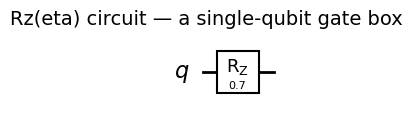

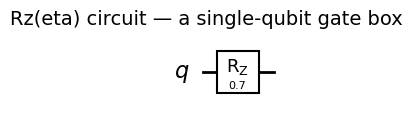

In [4]:
def Rn_matrix(n, eta):
    '''Builds Rn(eta) = cos(eta/2) I - i sin(eta/2) (n.sigma), directly from Eq. 3.8'''
    n = np.array(n) / np.linalg.norm(n)
    sx = np.array([[0, 1], [1, 0]])
    sy = np.array([[0, -1j], [1j, 0]])
    sz = np.array([[1, 0], [0, -1]])
    ndotsigma = n[0]*sx + n[1]*sy + n[2]*sz
    I = np.eye(2)
    return np.cos(eta/2)*I - 1j*np.sin(eta/2)*ndotsigma

def equal_up_to_phase(A, B, atol=1e-6):
    idx = np.unravel_index(np.argmax(np.abs(B)), B.shape)
    phase = A[idx] / B[idx]
    ok = np.allclose(A, phase * B, atol=atol)
    return ok, phase

eta0 = 0.7
n_axis = [0, 0, 1]
qc_rz_test = QuantumCircuit(1, name='Rz(eta) test')
qc_rz_test.rz(eta0, 0)
show_circuit(qc_rz_test, 'Rz(eta) circuit — a single-qubit gate box')

In [5]:
U_qiskit = Operator(qc_rz_test).data
U_notes = Rn_matrix(n_axis, eta0)
print('Rz(eta) from Qiskit:')
print(U_qiskit)
print('Rn(eta) from Eq. 3.8 with n = z:')
print(U_notes)
print('Match:', np.allclose(U_qiskit, U_notes))

Rz(eta) from Qiskit:
[[0.939-0.343j 0.   +0.j   ]
 [0.   +0.j    0.939+0.343j]]
Rn(eta) from Eq. 3.8 with n = z:
[[0.939-0.343j 0.   +0.j   ]
 [0.   +0.j    0.939+0.343j]]
Match: True


### Measurement in the Z basis vs the X basis

A plain Rz rotation on |0> leaves measurement probabilities unchanged in the Z basis (it's a phase-only rotation, Eq. 3.13-3.15). To *see* its effect, we must measure in the X basis — i.e. apply H before measuring.

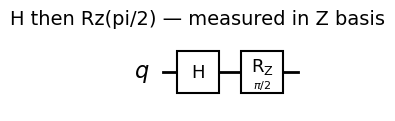

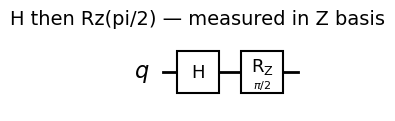

In [6]:
qc_zbasis = QuantumCircuit(1)
qc_zbasis.h(0)          # create superposition |+>
qc_zbasis.rz(np.pi/2, 0) # phase rotation
show_circuit(qc_zbasis, 'H then Rz(pi/2) — measured in Z basis')

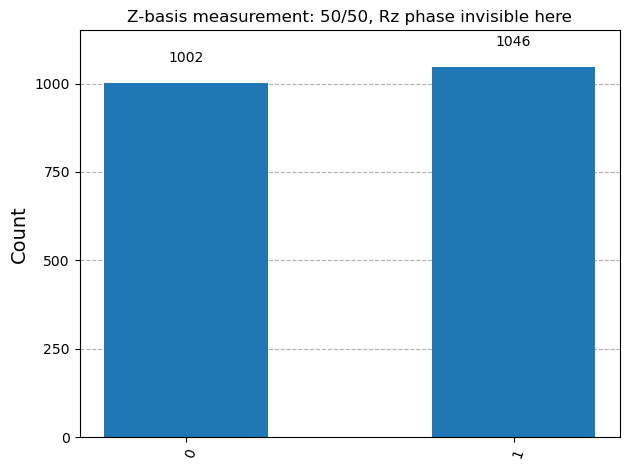

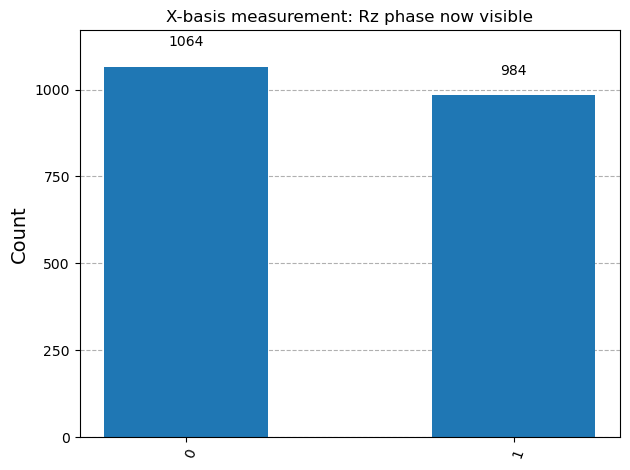

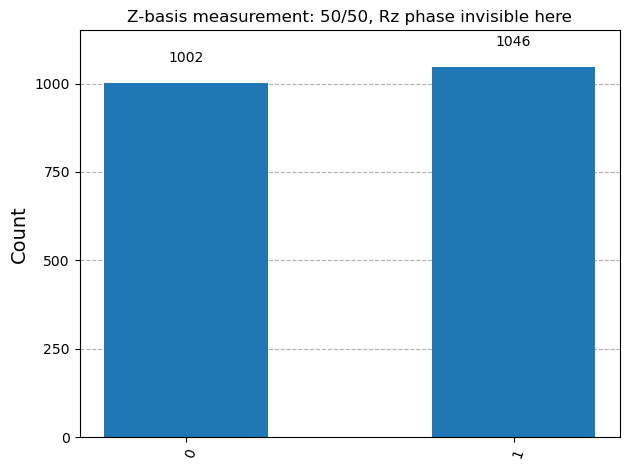

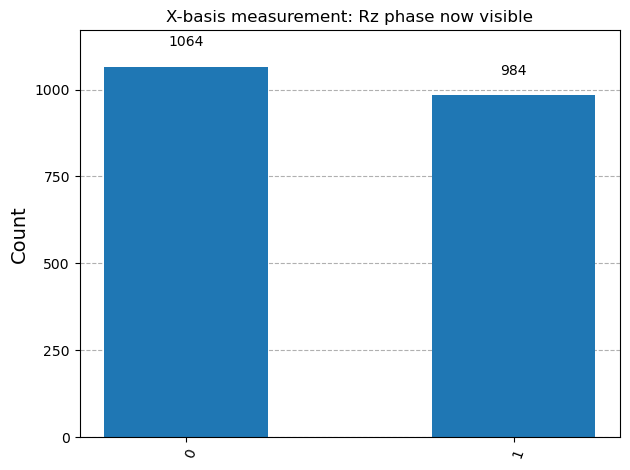

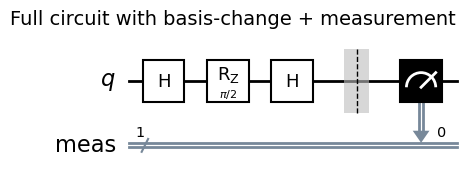

In [7]:
if AER_AVAILABLE:
    counts_z, fig_z, qcm_z = measure_and_plot(qc_zbasis, title='Z-basis measurement: 50/50, Rz phase invisible here')
    display(fig_z)

    qc_xbasis = qc_zbasis.copy()
    qc_xbasis.h(0)   # rotate X-basis info into Z basis before measuring
    counts_x, fig_x, qcm_x = measure_and_plot(qc_xbasis, title='X-basis measurement: Rz phase now visible')
    display(fig_x)
    show_circuit(qcm_x, 'Full circuit with basis-change + measurement')

## 1.1 Rn(eta) <=> Rotation of the Bloch Vector (Eq. 3.9 – 3.21)

Section 3.1.1 proves that Rn(eta) acting on |m> produces |m'>, the vector m rotated anticlockwise about n by eta:

- Rz(eta)|theta,phi> = |theta, phi+eta>   (Eq. 3.13 – 3.15)
- Rx(eta)|theta,pi/2> = |theta-eta, pi/2>  (Eq. 3.19 – 3.21)

Let's watch this happen on the Bloch sphere, with the generating circuit shown alongside.

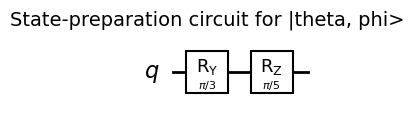

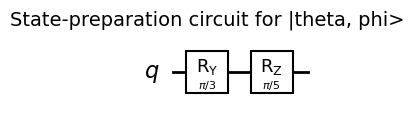

In [8]:
theta, phi, eta = np.pi/3, np.pi/5, np.pi/2

qc_in = QuantumCircuit(1, name='prepare |theta,phi>')
qc_in.ry(theta, 0)
qc_in.rz(phi, 0)
show_circuit(qc_in, 'State-preparation circuit for |theta, phi>')

Initial state |theta, phi>:


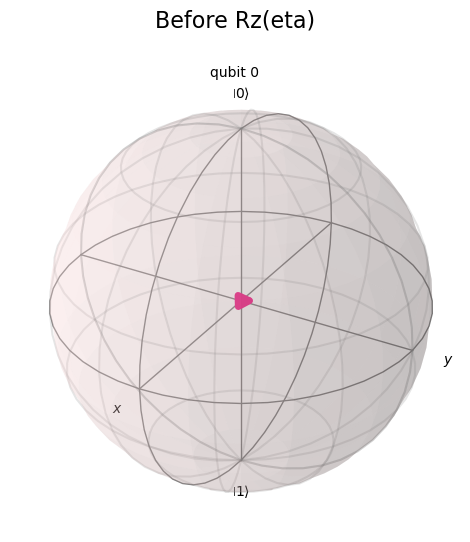

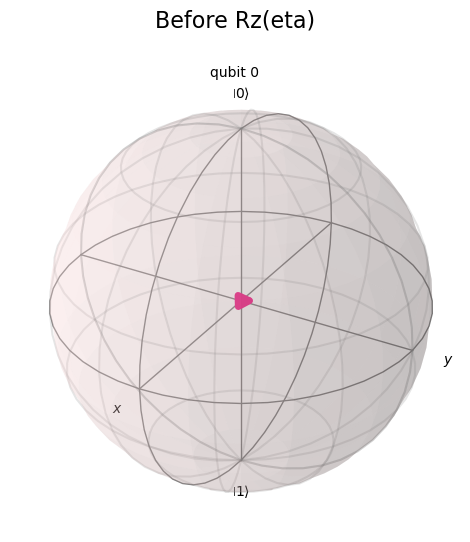

In [9]:
psi_in = Statevector(qc_in)
print('Initial state |theta, phi>:')
show_bloch(psi_in, 'Before Rz(eta)')

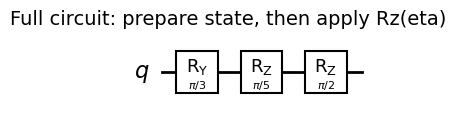

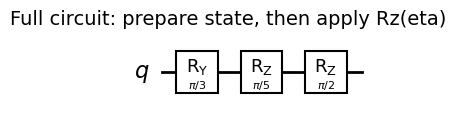

In [10]:
qc_out = qc_in.copy()
qc_out.rz(eta, 0)
psi_out = Statevector(qc_out)
show_circuit(qc_out, 'Full circuit: prepare state, then apply Rz(eta)')

After Rz(eta): expect |theta, phi + eta>


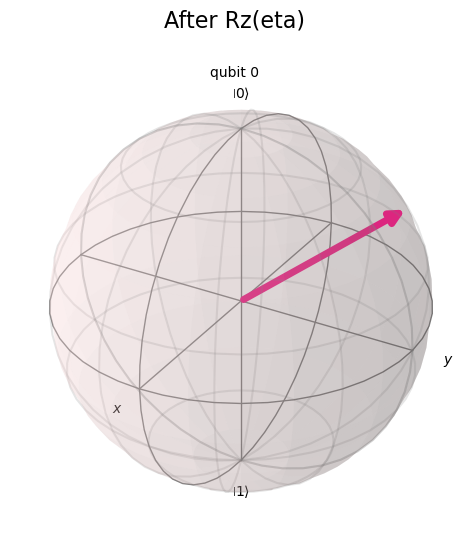

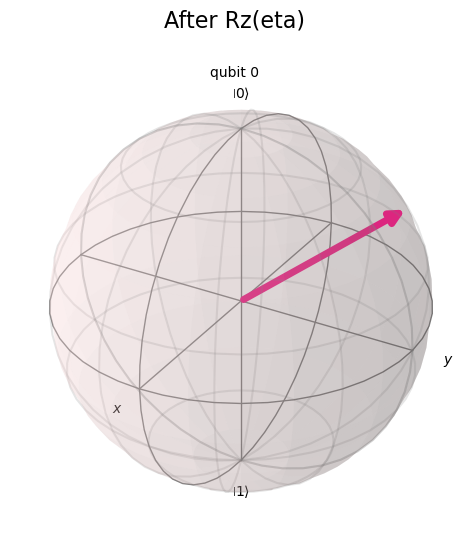

In [11]:
print('After Rz(eta): expect |theta, phi + eta>')
show_bloch(psi_out, 'After Rz(eta)')

In [12]:
def bloch_angles(sv):
    rho = DensityMatrix(sv).data
    x = 2*np.real(rho[0, 1])
    y = 2*np.imag(rho[1, 0])
    z = np.real(rho[0, 0] - rho[1, 1])
    theta_ = np.arccos(np.clip(z, -1, 1))
    phi_ = np.arctan2(y, x)
    return theta_, phi_

th_in, ph_in = bloch_angles(psi_in)
th_out, ph_out = bloch_angles(psi_out)
print(f'theta: {th_in:.3f} -> {th_out:.3f}  (should be unchanged)')
print(f'phi:   {ph_in:.3f} -> {ph_out:.3f}  (expected {(ph_in+eta):.3f} mod 2pi)')

theta: 1.047 -> 1.047  (should be unchanged)
phi:   0.628 -> 2.199  (expected 2.199 mod 2pi)


Now the Rx(eta) case: prepare a state in the y-z plane (phi = pi/2) and rotate about x. Theory (Eq. 3.19) predicts theta -> theta - eta while phi stays at pi/2.

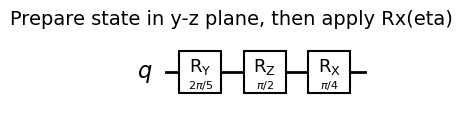

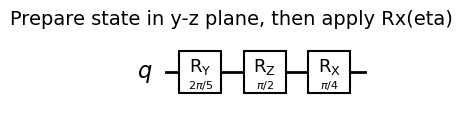

In [13]:
theta2, eta2 = 2*np.pi/5, np.pi/4
qc_in2 = QuantumCircuit(1)
qc_in2.ry(theta2, 0)
qc_in2.rz(np.pi/2, 0)
psi_in2 = Statevector(qc_in2)

qc_out2 = qc_in2.copy()
qc_out2.rx(eta2, 0)
psi_out2 = Statevector(qc_out2)

show_circuit(qc_out2, 'Prepare state in y-z plane, then apply Rx(eta)')

theta: 1.257 -> 0.471  (expected 0.471)
phi:   1.571 -> 1.571  (should stay pi/2 = 1.571)


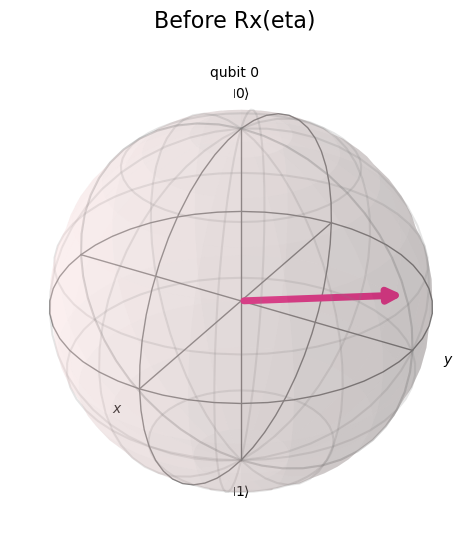

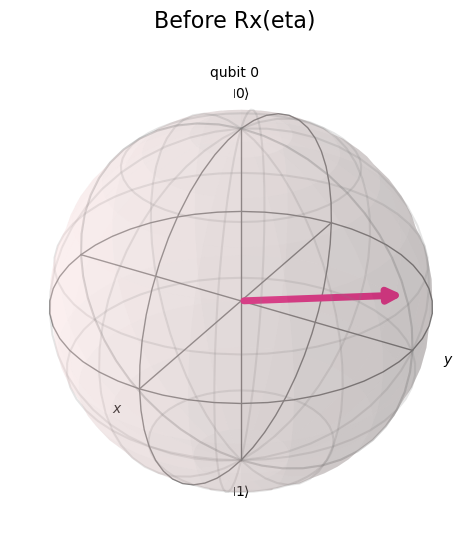

In [14]:
th_in2, ph_in2 = bloch_angles(psi_in2)
th_out2, ph_out2 = bloch_angles(psi_out2)
print(f'theta: {th_in2:.3f} -> {th_out2:.3f}  (expected {(th_in2-eta2):.3f})')
print(f'phi:   {ph_in2:.3f} -> {ph_out2:.3f}  (should stay pi/2 = {np.pi/2:.3f})')
show_bloch(psi_in2, 'Before Rx(eta)')

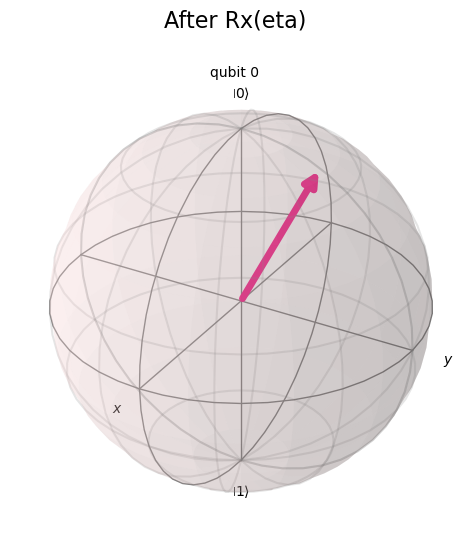

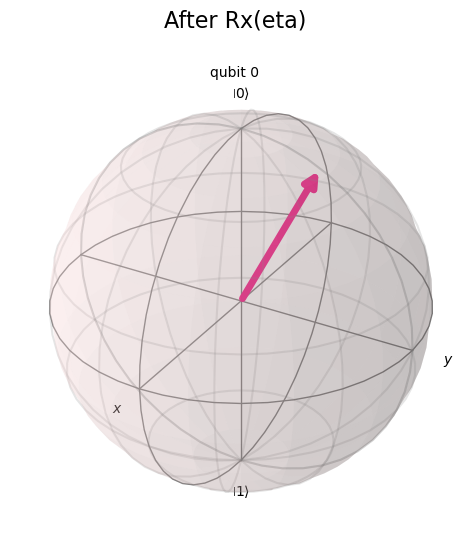

In [15]:
show_bloch(psi_out2, 'After Rx(eta)')

## 2. The Elementary Single-Qubit Gates (Sec. 3.1.2)

For every gate we now show: the **circuit diagram**, the **matrix**, the **Bloch-sphere action**, and — where the outcome is probabilistic — a **measurement histogram**.

In [16]:
def gate_report(name, build_fn, eq_ref='', input_label='0'):
    qc = QuantumCircuit(1, name=name)
    build_fn(qc)
    print(f'=== {name} gate {eq_ref} ===')
    fig_c = show_circuit(qc, f'{name} gate circuit')
    display(fig_c)
    U = Operator(qc).data
    print('Matrix:')
    print(np.round(U, 3))
    sv_in = Statevector.from_label(input_label)
    full = QuantumCircuit(1)
    if input_label == '1':
        full.x(0)
    full.compose(qc, inplace=True)
    sv_out = Statevector(full)
    print(f'{name}|{input_label}> = {sv_out.data.round(3)}')
    display(show_bloch(sv_out, f'{name}|{input_label}> on Bloch sphere'))
    return qc

### 2.1 X gate (NOT gate) — Eq. 3.28 – 3.31

X|0> = |1>,  X|1> = |0>.  Also X = i*exp(-i pi X/2) (Eq. 3.31): a pi-rotation about the x-axis (up to phase). Since X on a basis state is deterministic, measurement gives a single spike.

=== X gate (Eq. 3.28) ===


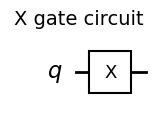

Matrix:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
X|0> = [0.+0.j 1.+0.j]


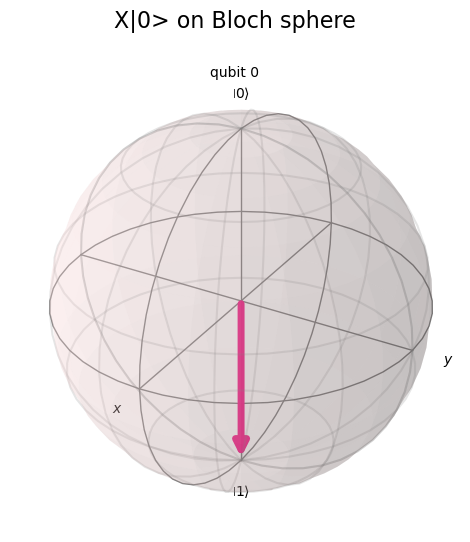

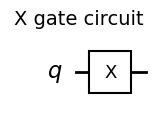

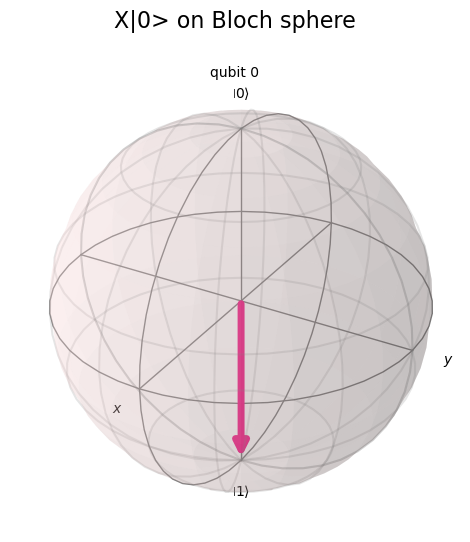

In [17]:
qc_x = gate_report('X', lambda qc: qc.x(0), '(Eq. 3.28)')

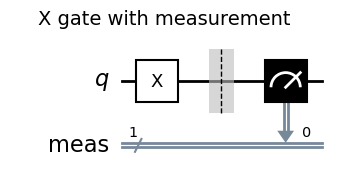

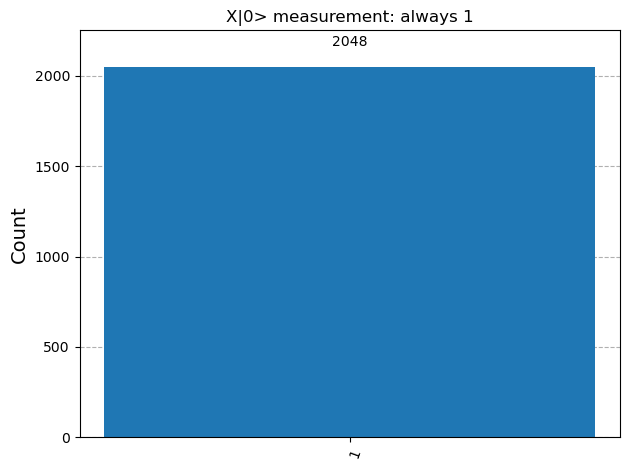

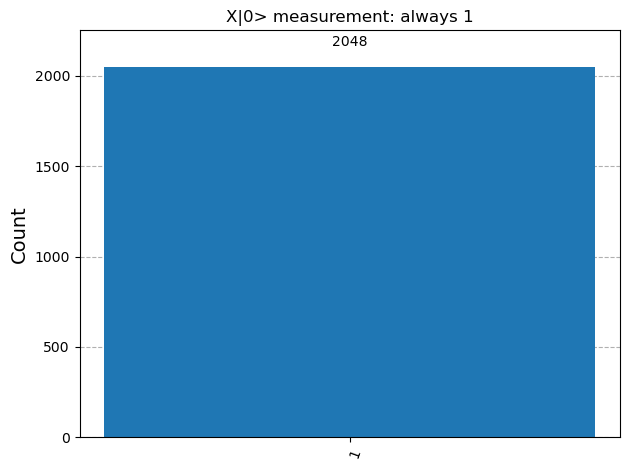

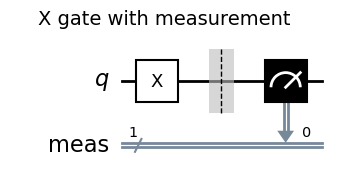

In [18]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_x, title='X|0> measurement: always 1')
    display(show_circuit(qcm, 'X gate with measurement'))
    display(fig)

### 2.2 Y gate — Eq. 3.32 – 3.35

Y|0> = i|1>,  Y|1> = -i|0>.

=== Y gate (Eq. 3.32) ===


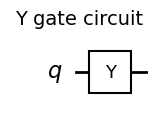

Matrix:
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
Y|0> = [0.+0.j 0.+1.j]


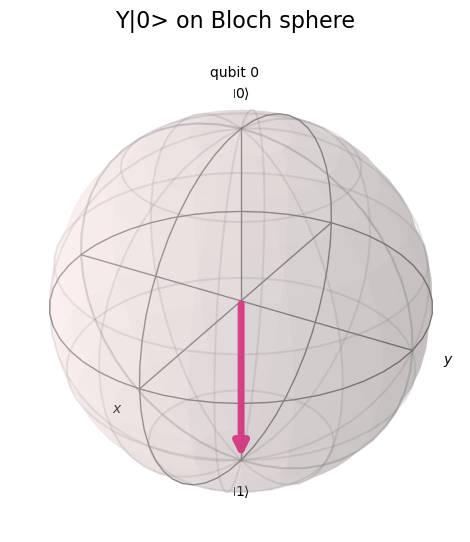

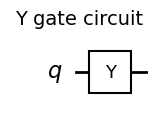

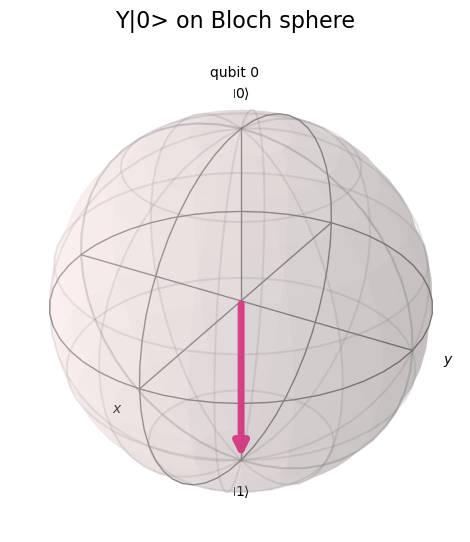

In [19]:
qc_y = gate_report('Y', lambda qc: qc.y(0), '(Eq. 3.32)')

### 2.3 Z gate — Eq. 3.36 – 3.39

Z|0> = |0>,  Z|1> = -|1>. A pi phase-flip. The Z-basis measurement of Z|0> looks identical to |0> (phase is invisible in Z-basis) — we again need an X-basis (Hadamard) measurement to reveal the sign flip.

=== Z gate (Eq. 3.36) ===


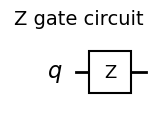

Matrix:
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
Z|1> = [ 0.+0.j -1.+0.j]


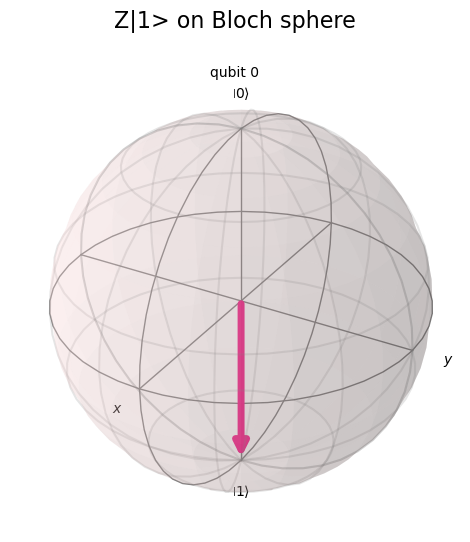

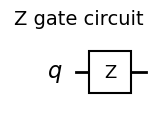

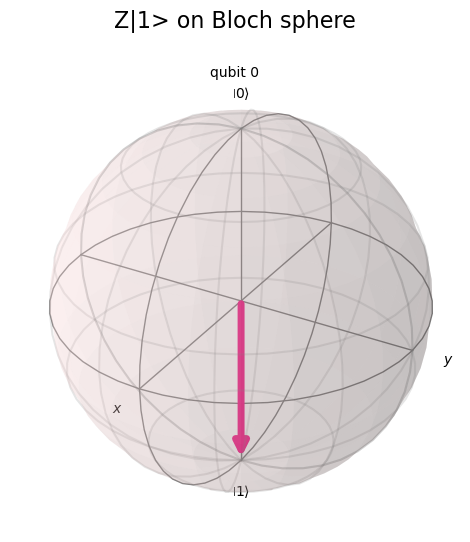

In [20]:
qc_z = gate_report('Z', lambda qc: qc.z(0), '(Eq. 3.36)', input_label='1')

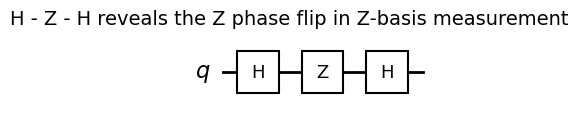

In [21]:
if AER_AVAILABLE:
    qc_zphase = QuantumCircuit(1)
    qc_zphase.h(0)
    qc_zphase.z(0)
    qc_zphase.h(0)
    show_circuit(qc_zphase, 'H - Z - H reveals the Z phase flip in Z-basis measurement')

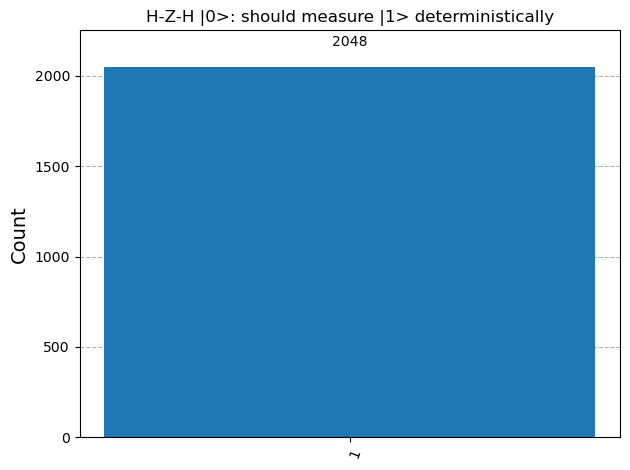

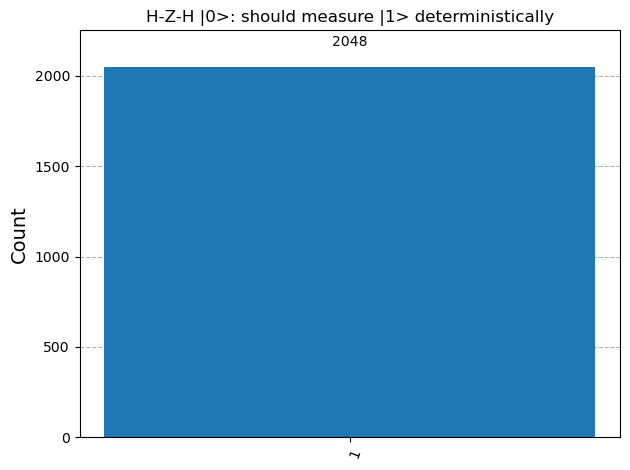

In [22]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_zphase, title='H-Z-H |0>: should measure |1> deterministically')
    display(fig)

### 2.4 T (pi/8) gate — Eq. 3.40 – 3.43

T|0> = |0>,  T|1> = exp(i pi/4)|1>. Called the 'pi/8 gate' because, up to a global phase exp(i pi/8), it equals diag(exp(-i pi/8), exp(i pi/8)) = exp(-i pi Z/8).

=== T gate (Eq. 3.40) ===


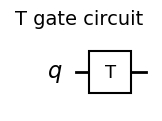

Matrix:
[[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]
T|1> = [0.   +0.j    0.707+0.707j]


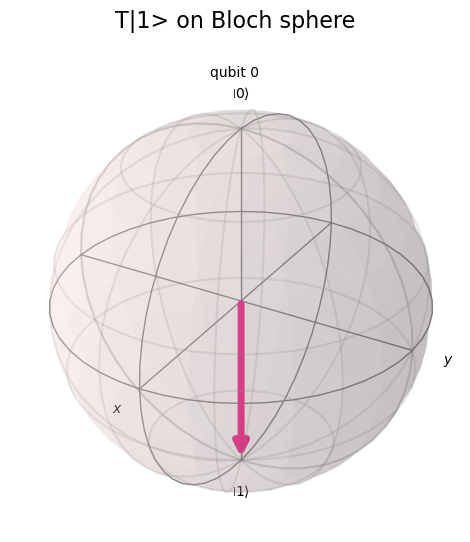

T from Eq. 3.43:
[[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]
Matches Qiskit T gate: True


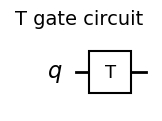

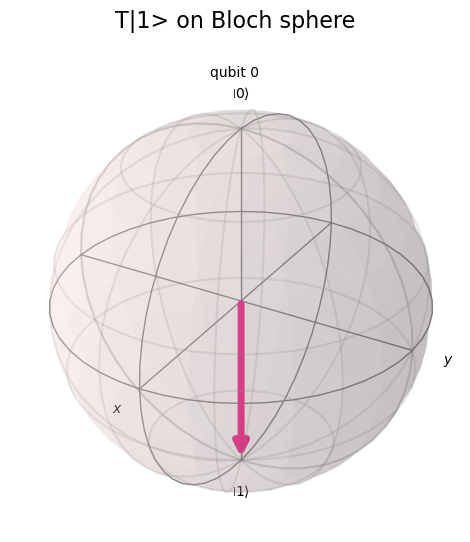

In [23]:
qc_t = gate_report('T', lambda qc: qc.t(0), '(Eq. 3.40)', input_label='1')

Z_mat = np.array([[1, 0], [0, -1]])
T_formula = np.exp(1j*np.pi/8) * (np.cos(np.pi/8)*np.eye(2) - 1j*np.sin(np.pi/8)*Z_mat)
print('T from Eq. 3.43:')
print(np.round(T_formula, 3))
print('Matches Qiskit T gate:', np.allclose(Operator(qc_t).data, T_formula))

### 2.5 S gate — Eq. 3.44 – 3.48

S|0> = |0>,  S|1> = i|1>.  Note S = T^2 (Eq. 3.48).

=== S gate (Eq. 3.44) ===


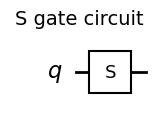

Matrix:
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
S|1> = [0.+0.j 0.+1.j]


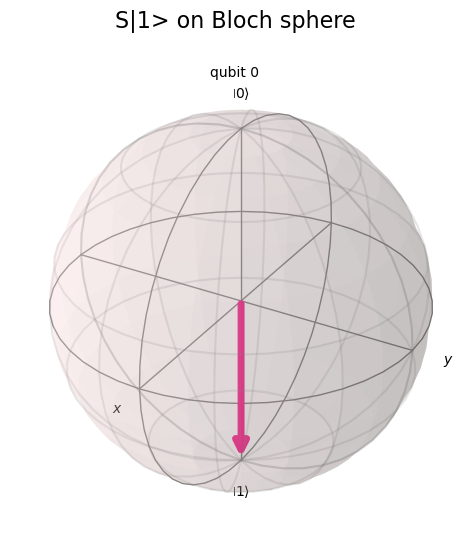

T^2 == S ? True


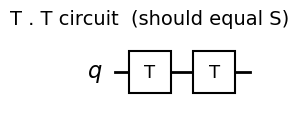

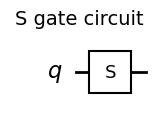

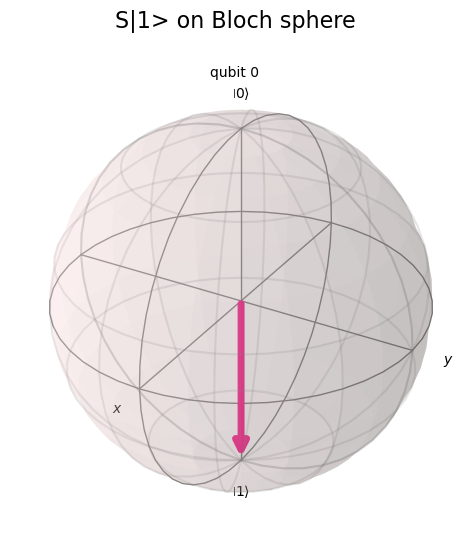

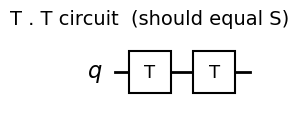

In [24]:
qc_s = gate_report('S', lambda qc: qc.s(0), '(Eq. 3.44)', input_label='1')

qc_t2 = QuantumCircuit(1)
qc_t2.t(0)
qc_t2.t(0)
print('T^2 == S ?', np.allclose(Operator(qc_t2).data, Operator(qc_s).data))
show_circuit(qc_t2, 'T . T circuit  (should equal S)')

### 2.6 Hadamard gate — Eq. 3.49 – 3.55

H|0> = (|0>+|1>)/sqrt(2),  H|1> = (|0>-|1>)/sqrt(2). In Pauli-matrix form: H = (X+Z)/sqrt(2) (Eq. 3.52) — a pi-rotation about the axis halfway between x and z. Because the outcome is a genuine 50/50 superposition, the measurement histogram is the most interesting one yet.

=== H gate (Eq. 3.49) ===


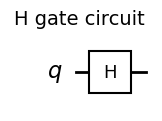

Matrix:
[[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
H|0> = [0.707+0.j 0.707+0.j]


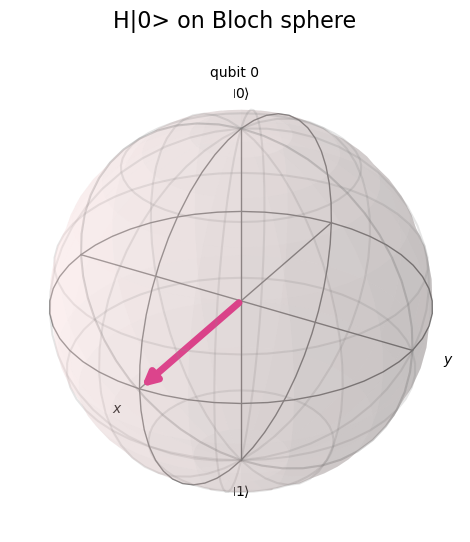

H = (X+Z)/sqrt(2)  (Eq. 3.52):
[[ 0.707  0.707]
 [ 0.707 -0.707]]
Matches Qiskit H gate: True


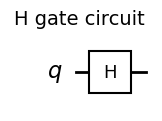

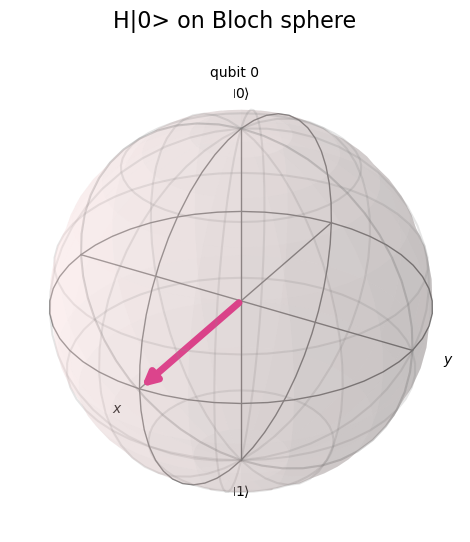

In [25]:
qc_h = gate_report('H', lambda qc: qc.h(0), '(Eq. 3.49)')

X_mat = np.array([[0, 1], [1, 0]])
Z_mat = np.array([[1, 0], [0, -1]])
H_formula = (X_mat + Z_mat) / np.sqrt(2)
print('H = (X+Z)/sqrt(2)  (Eq. 3.52):')
print(np.round(H_formula, 3))
print('Matches Qiskit H gate:', np.allclose(Operator(qc_h).data, H_formula))

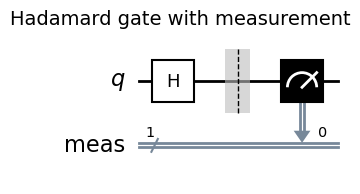

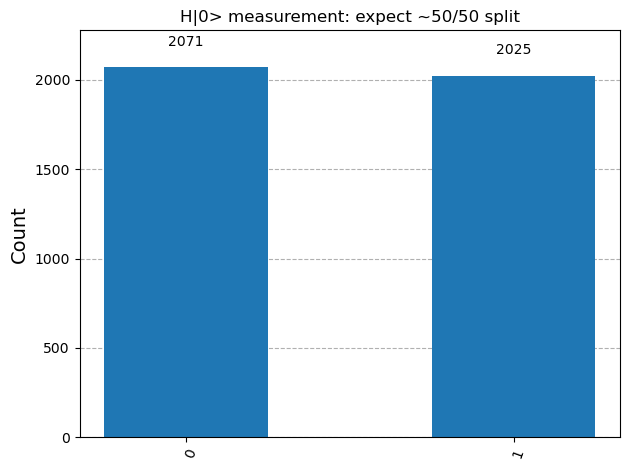

Counts: {'0': 2071, '1': 2025}


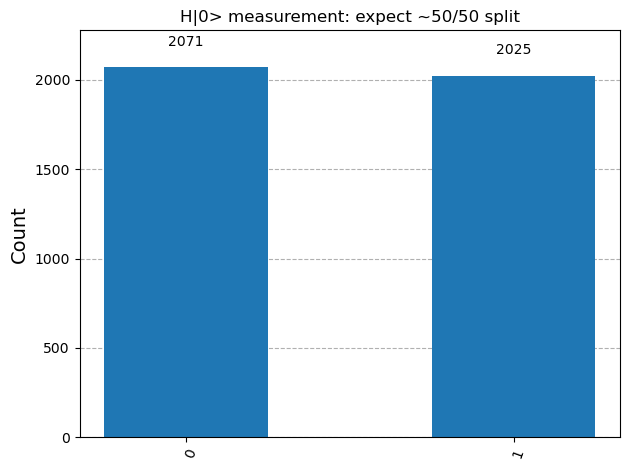

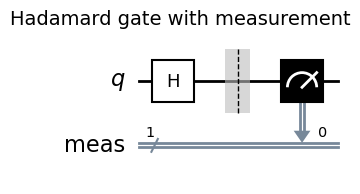

In [26]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_h, shots=4096, title='H|0> measurement: expect ~50/50 split')
    display(show_circuit(qcm, 'Hadamard gate with measurement'))
    display(fig)
    print('Counts:', counts)

## 3. Single-Qubit Universal Gates: H and T (Sec. 3.1.3)

The notes prove that repeated application of H and T can approximate ANY single-qubit unitary to arbitrary accuracy, because:

  H T H = exp(i pi/8) (cos(pi/8) I - i sin(pi/8) X)   (Eq. 3.56)

  T H T H = Rp(eta), with cos(eta/2) = cos^2(pi/8)   (Eq. 3.60 – 3.71)

and eta/pi is irrational, so repeated applications of Rp(eta) never exactly repeat and densely fill all rotation angles about the fixed axis p.

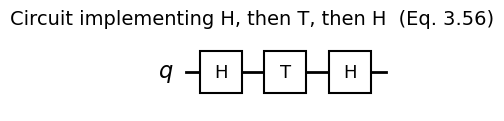

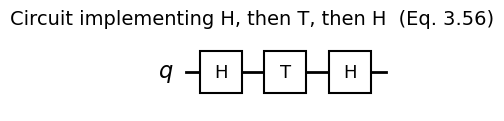

In [27]:
qc_hth = QuantumCircuit(1, name='H.T.H')
qc_hth.h(0)
qc_hth.t(0)
qc_hth.h(0)
show_circuit(qc_hth, 'Circuit implementing H, then T, then H  (Eq. 3.56)')

In [28]:
HTH = Operator(qc_hth).data
print('Matrix of H.T.H:')
print(np.round(HTH, 3))
formula = np.exp(1j*np.pi/8) * (np.cos(np.pi/8)*np.eye(2) - 1j*np.sin(np.pi/8)*X_mat)
print('Formula from Eq. 3.56:')
print(np.round(formula, 3))
print('Exact match:', np.allclose(HTH, formula))

Matrix of H.T.H:
[[0.854+0.354j 0.146-0.354j]
 [0.146-0.354j 0.854+0.354j]]
Formula from Eq. 3.56:
[[0.854+0.354j 0.146-0.354j]
 [0.146-0.354j 0.854+0.354j]]
Exact match: True


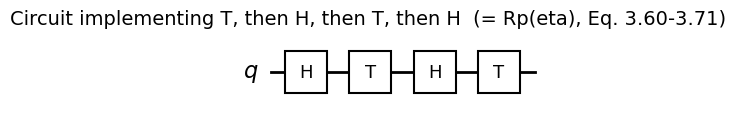

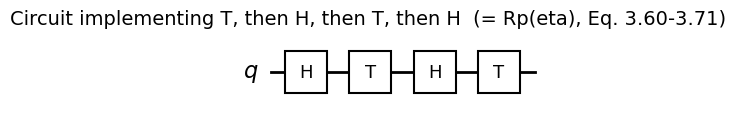

In [29]:
qc_thth = QuantumCircuit(1, name='T.H.T.H')
qc_thth.h(0)
qc_thth.t(0)
qc_thth.h(0)
qc_thth.t(0)
show_circuit(qc_thth, 'Circuit implementing T, then H, then T, then H  (= Rp(eta), Eq. 3.60-3.71)')

In [30]:
THTH = Operator(qc_thth).data
eta_p = 2*np.arccos(np.cos(np.pi/8)**2)
print('eta (Eq. 3.71) =', eta_p, ' ; eta/pi =', eta_p/np.pi, ' (irrational -> gate never exactly repeats)')

p_axis = np.array([np.cos(np.pi/8), np.sin(np.pi/8), np.cos(np.pi/8)])
Rp_eta = Rn_matrix(p_axis, eta_p)
ok, phase = equal_up_to_phase(THTH, Rp_eta)
print('T.H.T.H equals Rp(eta) up to global phase?', ok)

eta (Eq. 3.71) = 1.0960568152406256  ; eta/pi = 0.34888572011021163  (irrational -> gate never exactly repeats)
T.H.T.H equals Rp(eta) up to global phase? True


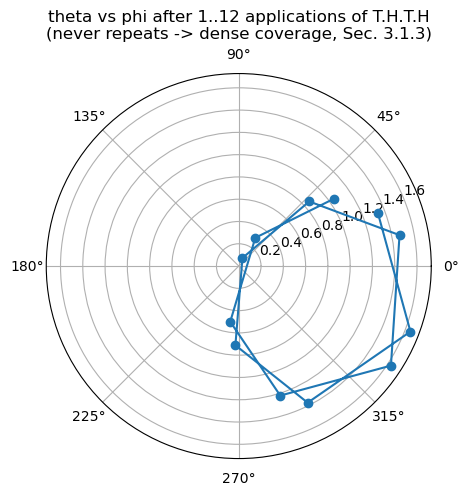

In [31]:
if AER_AVAILABLE:
    # visualize how repeated Rp(eta) fills the Bloch sphere densely (irrational rotation)
    qc_repeat = QuantumCircuit(1)
    qc_repeat.h(0)  # start from an equator state to see the spiral clearly
    thetas, phis = [], []
    for reps in range(1, 13):
        qc_r = QuantumCircuit(1)
        qc_r.h(0)
        for _ in range(reps):
            qc_r.t(0); qc_r.h(0); qc_r.t(0); qc_r.h(0)
        sv = Statevector(qc_r)
        th, ph = bloch_angles(sv)
        thetas.append(th); phis.append(ph)
    plt.figure(figsize=(5,5))
    ax = plt.subplot(111, projection='polar')
    ax.plot(phis, thetas, 'o-')
    ax.set_title('theta vs phi after 1..12 applications of T.H.T.H\n(never repeats -> dense coverage, Sec. 3.1.3)')
    plt.show()

## 4. Multi-Qubit States and Controlled Gates (Sec. 3.1.4)

A controlled-U gate acts as:

  CU |a,b> = U2^a |a,b>   (Eq. 3.81)

i.e. U is applied to the target (second) qubit only when the control (first) qubit is |1>.

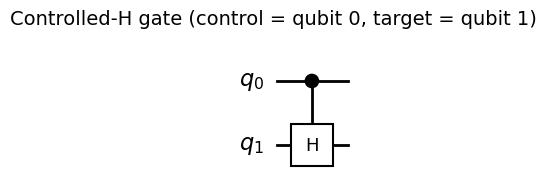

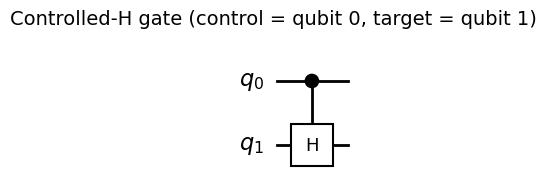

In [32]:
U = Operator(qc_h).data
cU = UnitaryGate(U, label='H').control(1)

qc_cu = QuantumCircuit(2, name='controlled-H')
qc_cu.append(cU, [0, 1])
show_circuit(qc_cu, 'Controlled-H gate (control = qubit 0, target = qubit 1)')

In [33]:
for a in ['0', '1']:
    for b in ['0', '1']:
        label = a + b
        out = Statevector.from_label(label).evolve(qc_cu)
        print(f'CU|{a},{b}> = {out.data.round(3)}')

CU|0,0> = [1.+0.j 0.-0.j 0.+0.j 0.-0.j]
CU|0,1> = [-0.   -0.j  0.707+0.j -0.   -0.j  0.707+0.j]
CU|1,0> = [-0.+0.j  0.-0.j  1.-0.j  0.-0.j]
CU|1,1> = [-0.   -0.j  0.707-0.j  0.   -0.j -0.707+0.j]


### 4.1 CNOT / Controlled-X gate — Eq. 3.82

CX|a,b> = |a, b XOR a>. Below: full circuit diagrams AND measurement histograms for all four computational-basis inputs, plus the famous Bell-state case (control in superposition).

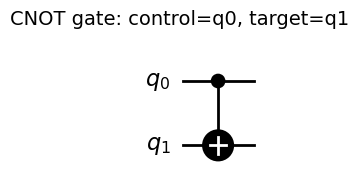

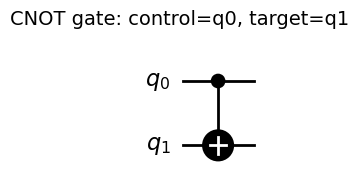

In [34]:
qc_cx = QuantumCircuit(2, name='CNOT')
qc_cx.cx(0, 1)
show_circuit(qc_cx, 'CNOT gate: control=q0, target=q1')

Truth table via MEASUREMENT (not just statevector algebra):
input a=0, b=0  ->  counts = {'00': 256}   (expect b_out = 0, a_out = 0)
input a=0, b=1  ->  counts = {'10': 256}   (expect b_out = 1, a_out = 0)
input a=1, b=0  ->  counts = {'11': 256}   (expect b_out = 1, a_out = 1)
input a=1, b=1  ->  counts = {'01': 256}   (expect b_out = 0, a_out = 1)


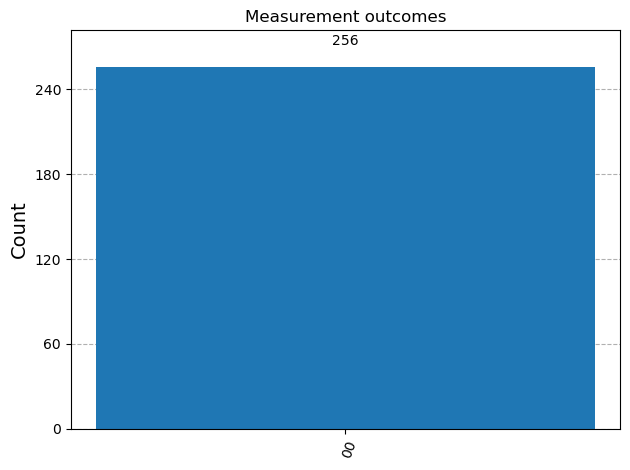

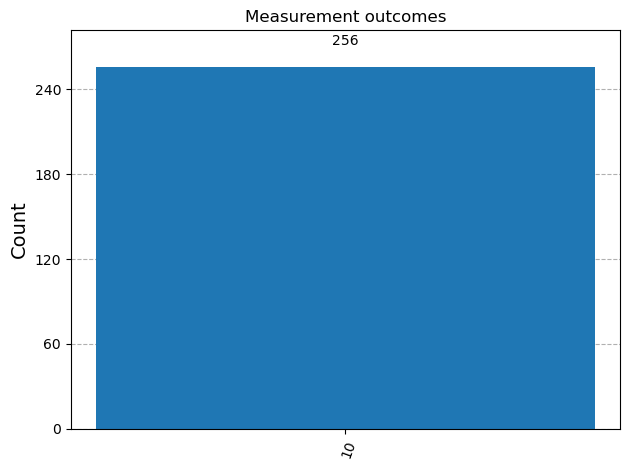

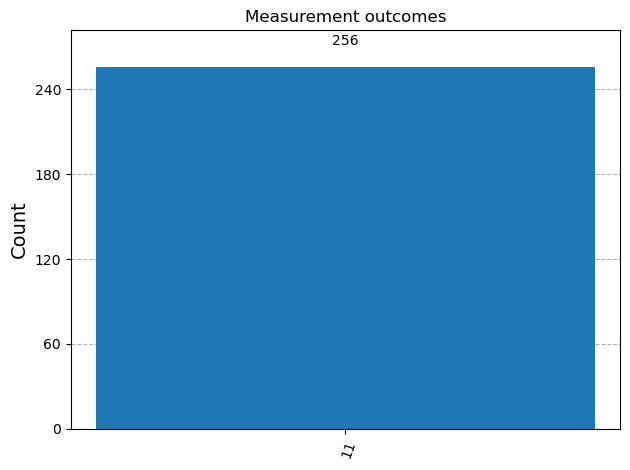

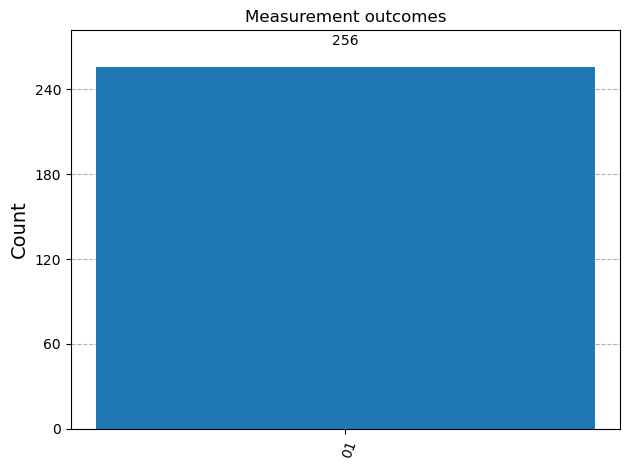

In [35]:
if AER_AVAILABLE:
    print('Truth table via MEASUREMENT (not just statevector algebra):')
    for a in [0, 1]:
        for b in [0, 1]:
            qc_test = QuantumCircuit(2)
            if a: qc_test.x(0)
            if b: qc_test.x(1)
            qc_test.cx(0, 1)
            counts, fig, qcm = measure_and_plot(qc_test, shots=256)
            print(f'input a={a}, b={b}  ->  counts = {counts}   (expect b_out = {a^b}, a_out = {a})')

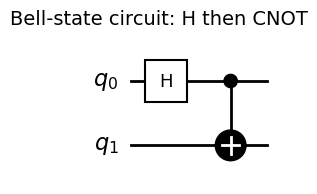

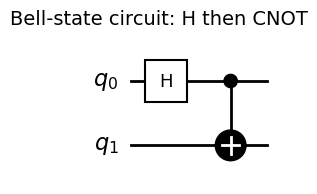

In [36]:
# The Bell state: H on control, then CNOT -> entanglement
qc_bell = QuantumCircuit(2, name='Bell state')
qc_bell.h(0)
qc_bell.cx(0, 1)
show_circuit(qc_bell, 'Bell-state circuit: H then CNOT')

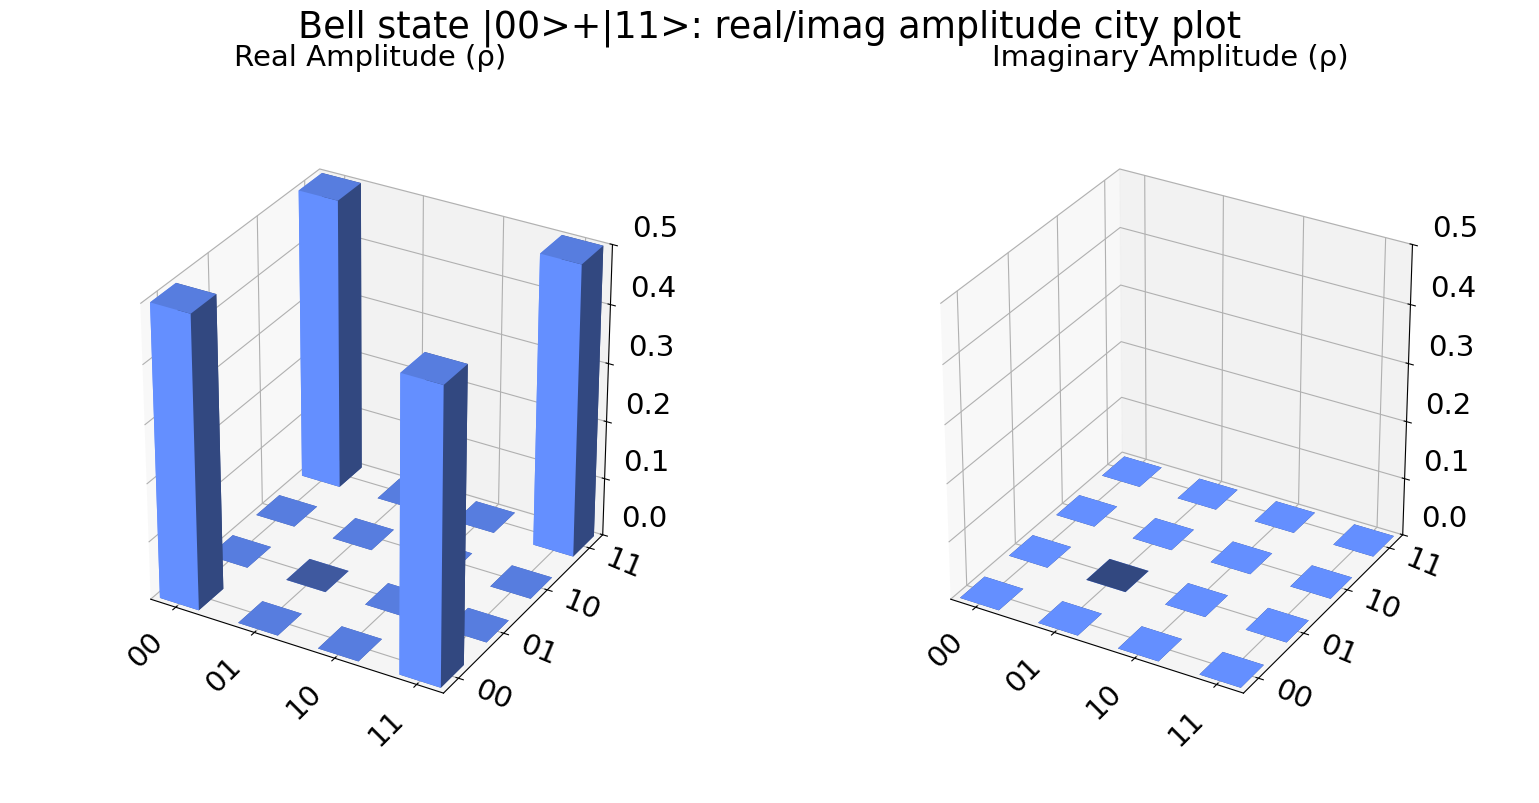

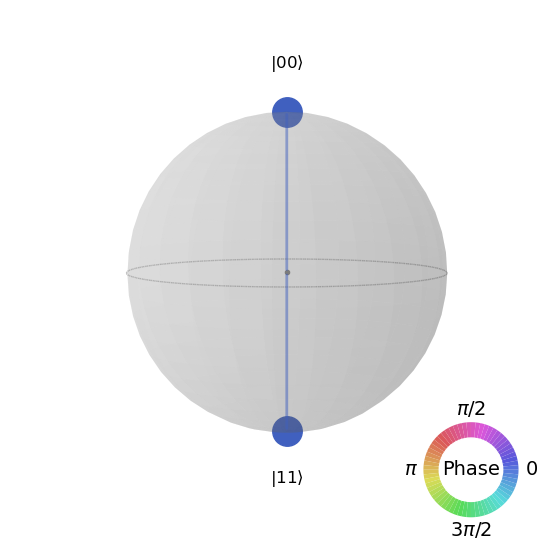

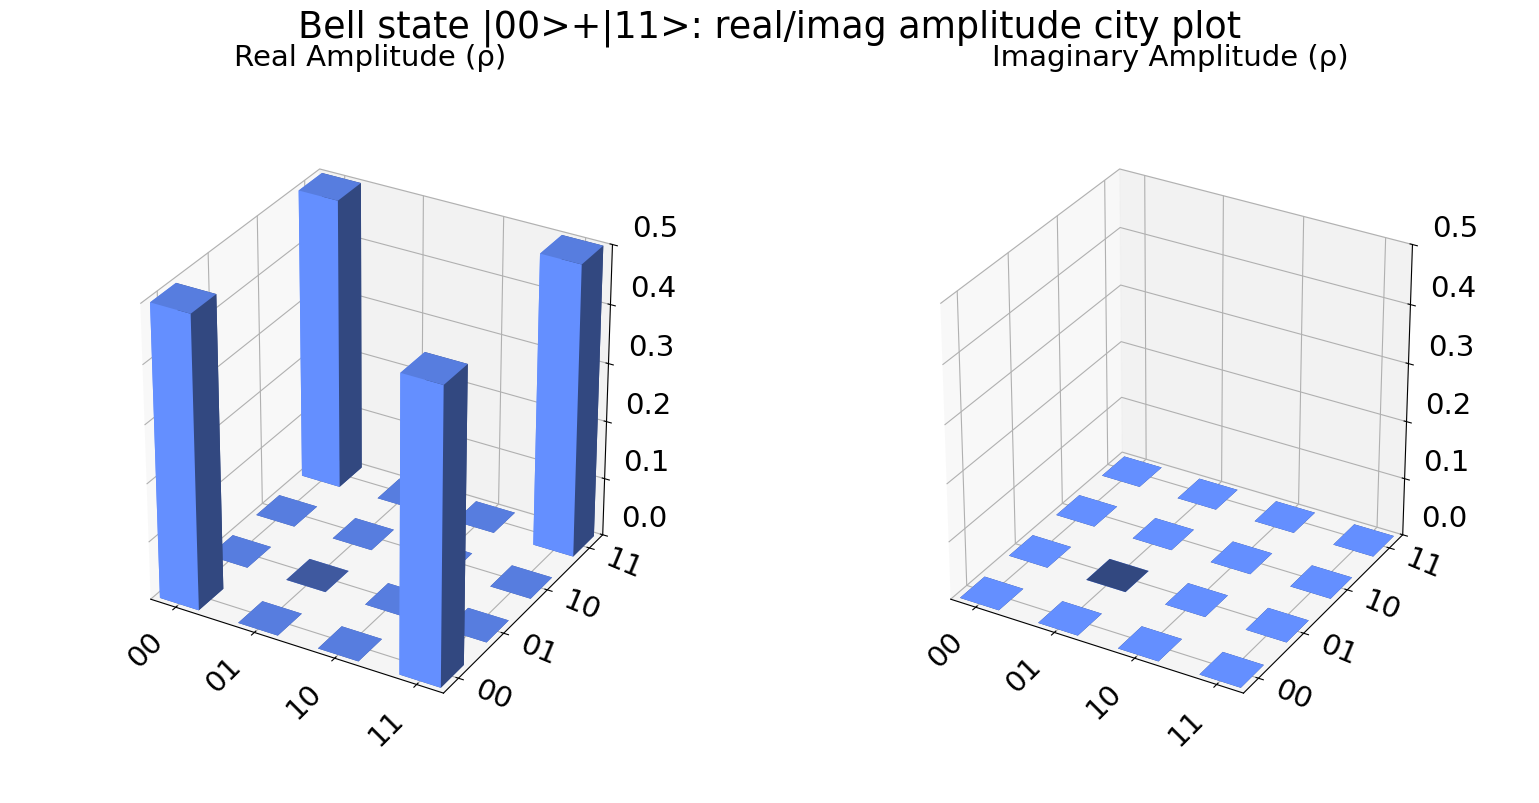

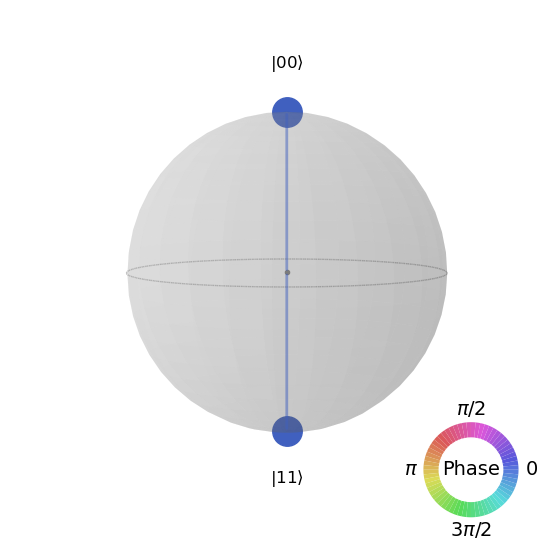

In [37]:
sv_bell = Statevector(qc_bell)
display(plot_state_city(sv_bell, title='Bell state |00>+|11>: real/imag amplitude city plot'))
display(plot_state_qsphere(sv_bell))

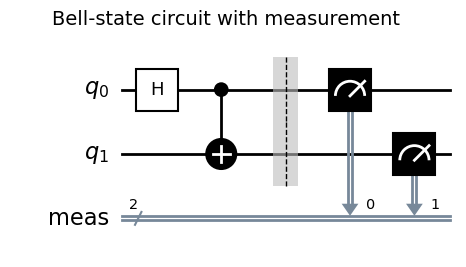

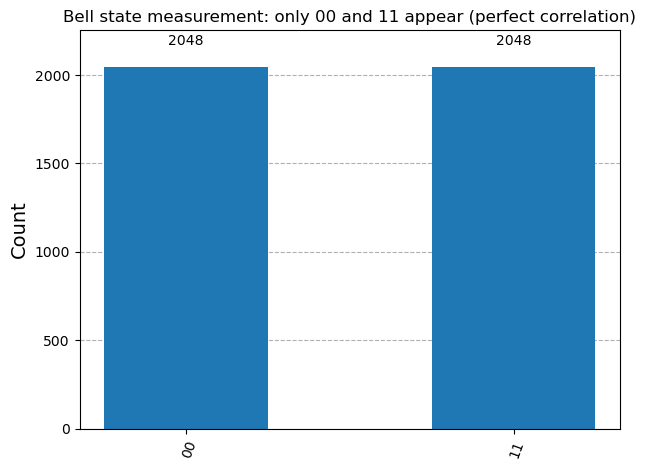

Counts: {'00': 2048, '11': 2048}


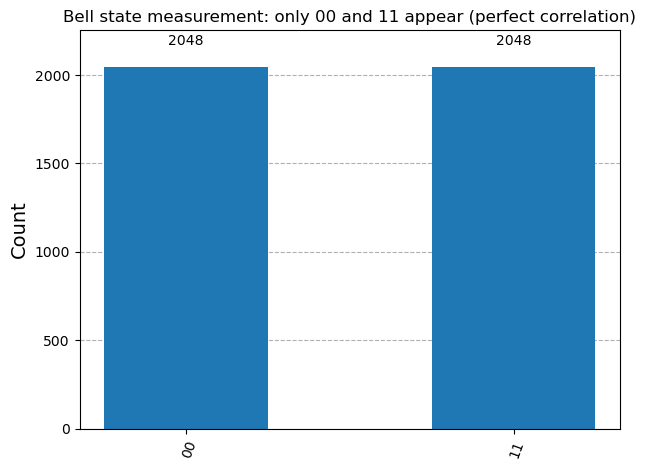

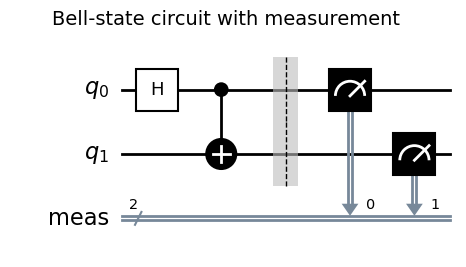

In [38]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_bell, shots=4096, title='Bell state measurement: only 00 and 11 appear (perfect correlation)')
    display(show_circuit(qcm, 'Bell-state circuit with measurement'))
    display(fig)
    print('Counts:', counts)

### 4.2 SWAP gate — Eq. 3.83 – 3.85, Fig. 3.10

SWAP exchanges the states of two qubits. Built from three CNOTs, as shown in the notes.

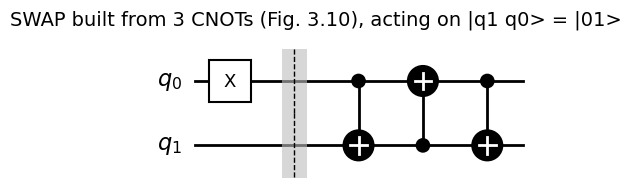

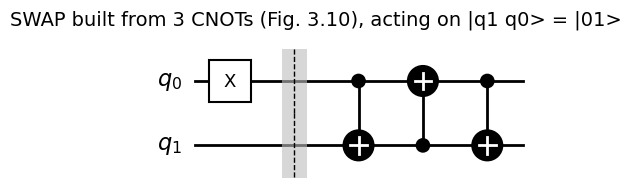

In [39]:
qc_swap_manual = QuantumCircuit(2, name='SWAP (3-CNOT)')
qc_swap_manual.x(0)  # prepare q0=1, q1=0 to make the swap visible
qc_swap_manual.barrier()
qc_swap_manual.cx(0, 1)
qc_swap_manual.cx(1, 0)
qc_swap_manual.cx(0, 1)
show_circuit(qc_swap_manual, 'SWAP built from 3 CNOTs (Fig. 3.10), acting on |q1 q0> = |01>')

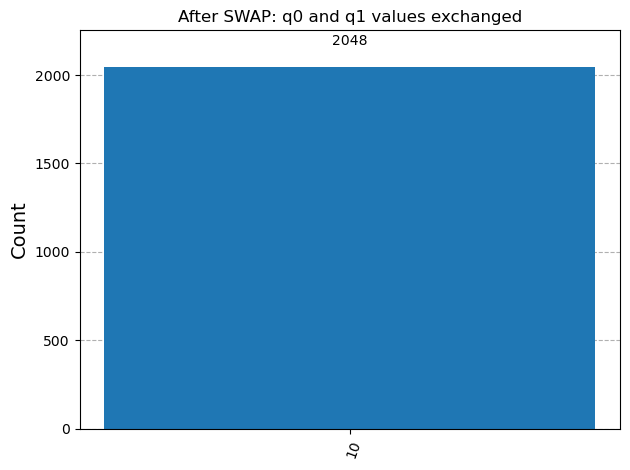

Counts: {'10': 2048}  (input was q0=1,q1=0 -> expect q0=0,q1=1 after swap)


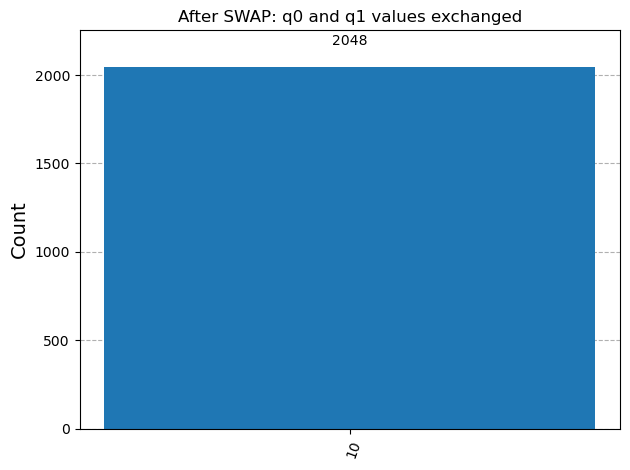

In [40]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_swap_manual, title='After SWAP: q0 and q1 values exchanged')
    display(fig)
    print('Counts:', counts, ' (input was q0=1,q1=0 -> expect q0=0,q1=1 after swap)')

### 4.3 Control-by-|0> vs Control-by-|1> — Fig. 3.11

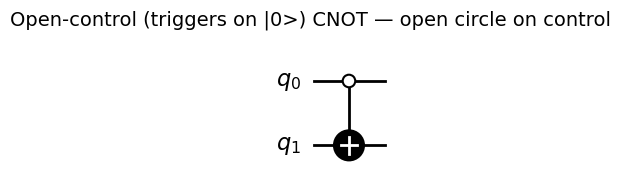

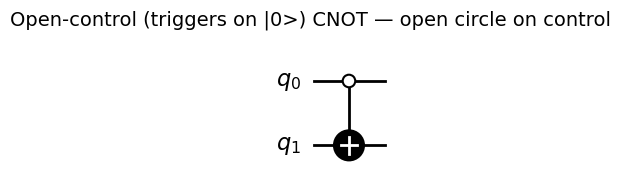

In [41]:
qc_open_ctrl = QuantumCircuit(2, name='open-control CX')
qc_open_ctrl.cx(0, 1, ctrl_state=0)
show_circuit(qc_open_ctrl, 'Open-control (triggers on |0>) CNOT — open circle on control')

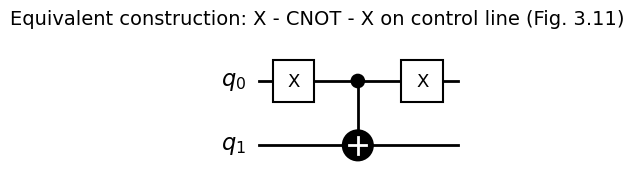

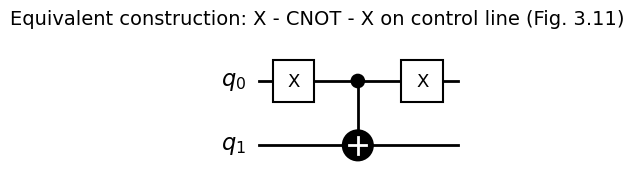

In [42]:
qc_via_X = QuantumCircuit(2, name='X-CX-X equivalent')
qc_via_X.x(0)
qc_via_X.cx(0, 1)
qc_via_X.x(0)
show_circuit(qc_via_X, 'Equivalent construction: X - CNOT - X on control line (Fig. 3.11)')

In [43]:
print('Open-control CX == X-CX-X ?', np.allclose(Operator(qc_open_ctrl).data, Operator(qc_via_X).data))

Open-control CX == X-CX-X ? True


## 5. n-Control Qubit Gates (Sec. 3.1.5)

### 5.1 Toffoli gate (CCX) — Fig. 3.12 – 3.13

C2_X |a,b,c> = |a, b, c XOR (a AND b)>. The target flips only when BOTH controls are |1>.

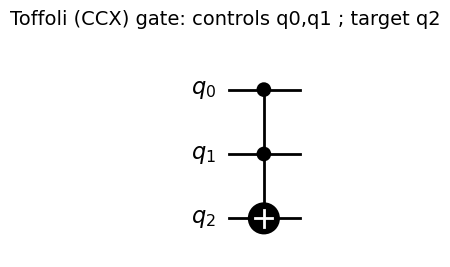

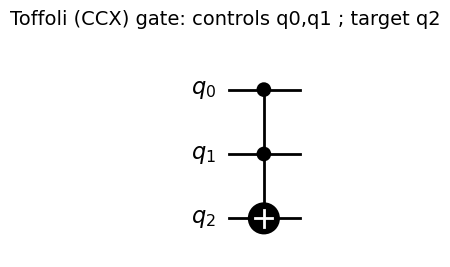

In [44]:
qc_ccx = QuantumCircuit(3, name='Toffoli')
qc_ccx.ccx(0, 1, 2)
show_circuit(qc_ccx, 'Toffoli (CCX) gate: controls q0,q1 ; target q2')

Truth table for Toffoli via MEASUREMENT:
a=0 b=0 c=0  ->  counts={'000': 256}  (expect c_out=0)
a=0 b=0 c=1  ->  counts={'100': 256}  (expect c_out=1)
a=0 b=1 c=0  ->  counts={'010': 256}  (expect c_out=0)
a=0 b=1 c=1  ->  counts={'110': 256}  (expect c_out=1)
a=1 b=0 c=0  ->  counts={'001': 256}  (expect c_out=0)
a=1 b=0 c=1  ->  counts={'101': 256}  (expect c_out=1)
a=1 b=1 c=0  ->  counts={'111': 256}  (expect c_out=1)
a=1 b=1 c=1  ->  counts={'011': 256}  (expect c_out=0)


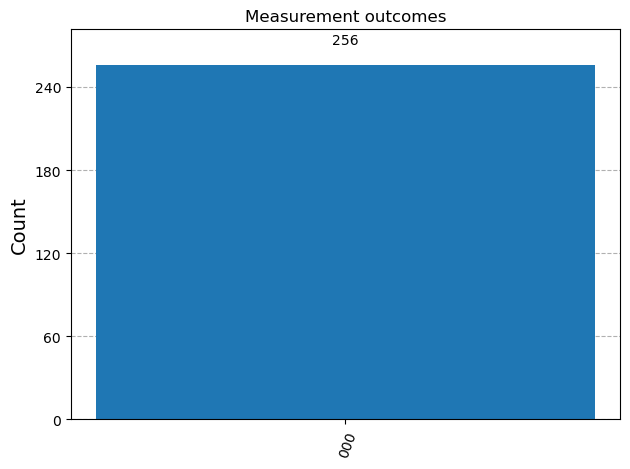

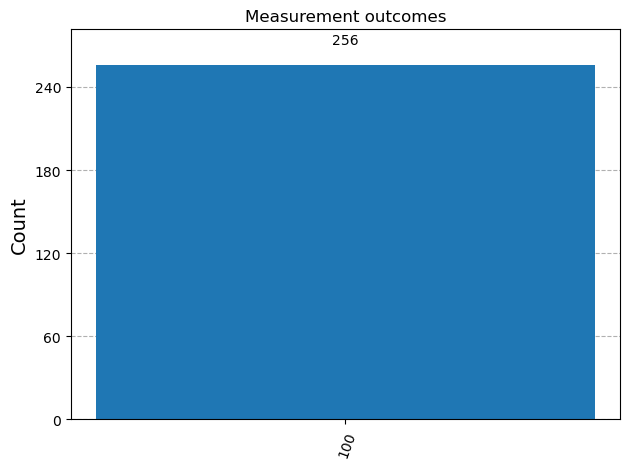

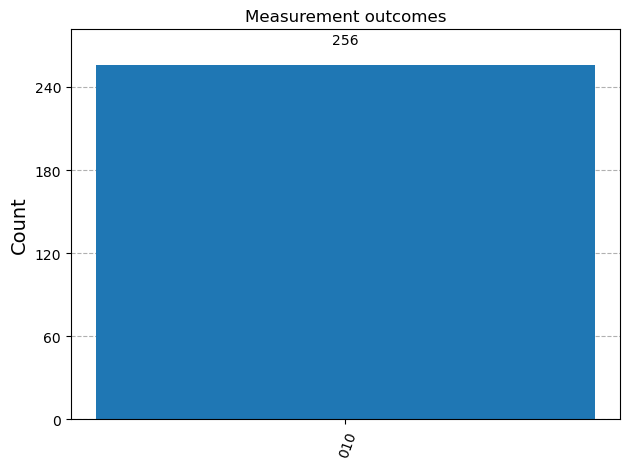

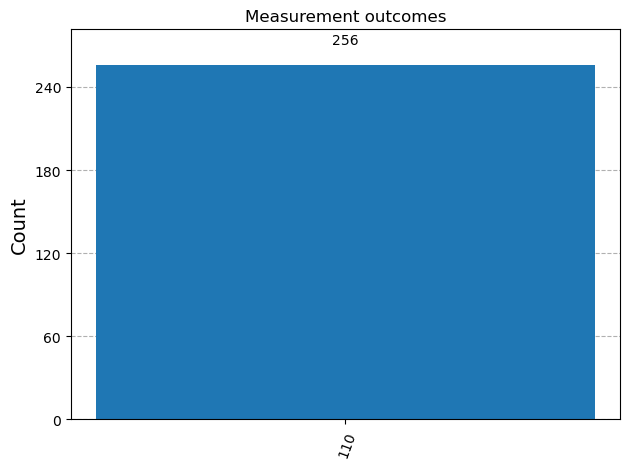

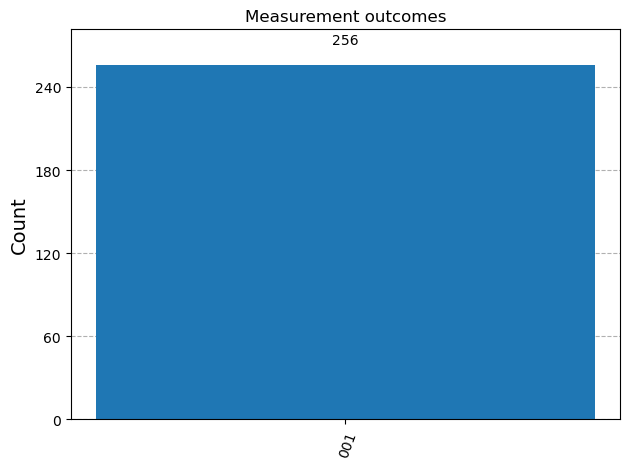

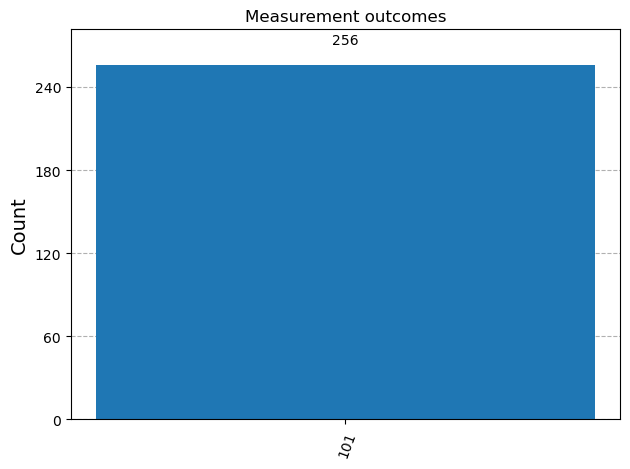

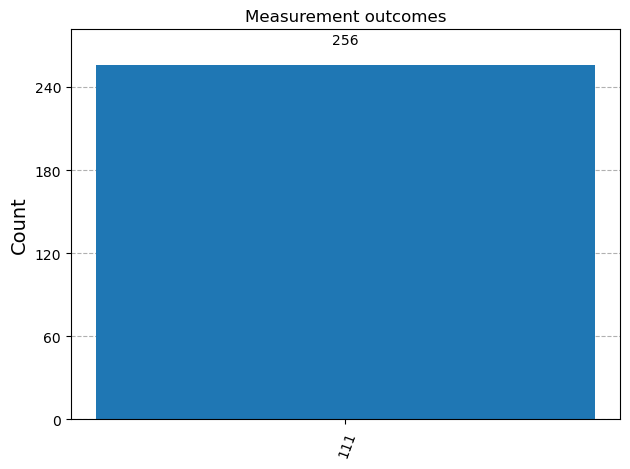

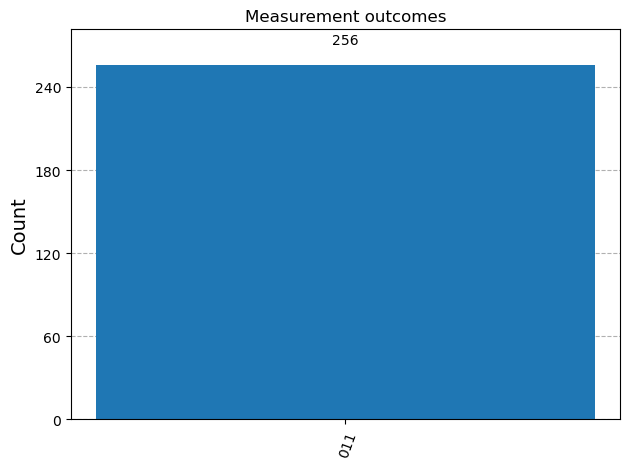

In [45]:
if AER_AVAILABLE:
    print('Truth table for Toffoli via MEASUREMENT:')
    for a in [0, 1]:
        for b in [0, 1]:
            for c in [0, 1]:
                qc_test = QuantumCircuit(3)
                if a: qc_test.x(0)
                if b: qc_test.x(1)
                if c: qc_test.x(2)
                qc_test.ccx(0, 1, 2)
                counts, fig, qcm = measure_and_plot(qc_test, shots=256)
                print(f'a={a} b={b} c={c}  ->  counts={counts}  (expect c_out={c ^ (a & b)})')

### 5.2 Multi-Controlled-X (Cn gate) — Fig. 3.15

Any Cn_U gate can be decomposed into single-qubit-controlled gates (repeated use of Eq. 3.27). Qiskit's MCXGate implements this directly — let's draw its decomposition AND measure it.

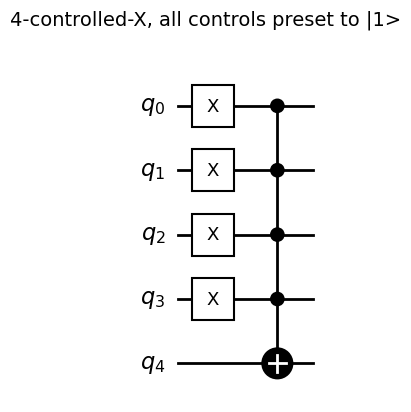

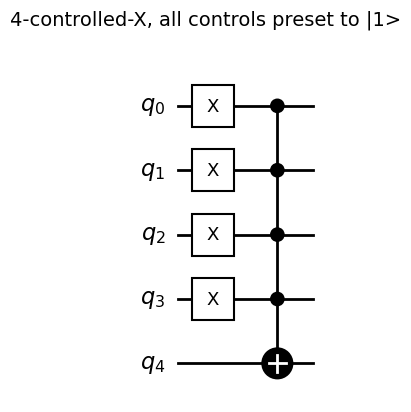

In [46]:
n_controls = 4
mcx = MCXGate(n_controls)
qc_mcx = QuantumCircuit(n_controls + 1, name=f'{n_controls}-controlled-X')
for q in range(n_controls):
    qc_mcx.x(q)  # set all controls to |1>
qc_mcx.append(mcx, range(n_controls + 1))
show_circuit(qc_mcx, f'{n_controls}-controlled-X, all controls preset to |1>')

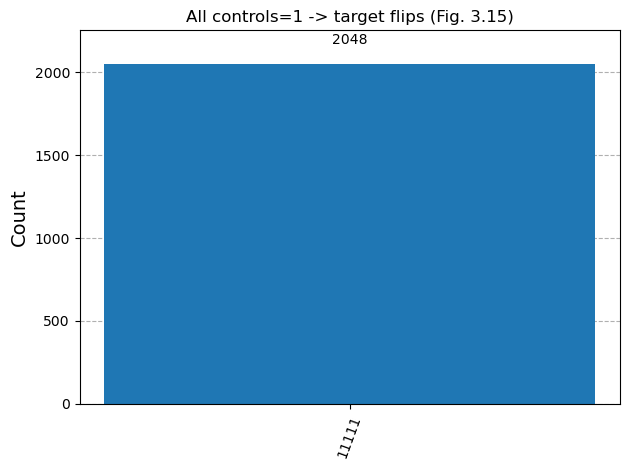

Counts: {'11111': 2048}


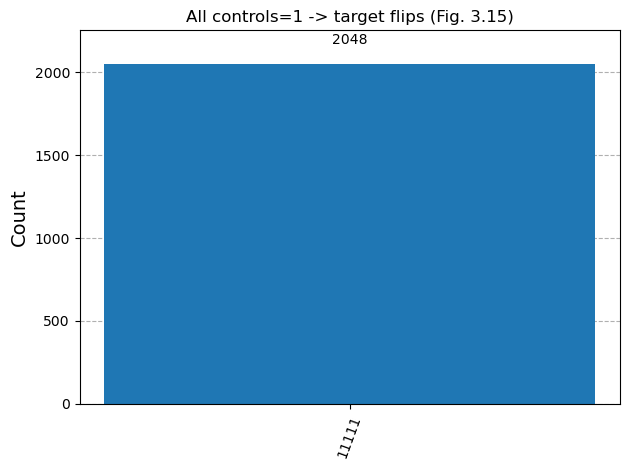

In [47]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_mcx, title='All controls=1 -> target flips (Fig. 3.15)')
    display(fig)
    print('Counts:', counts)

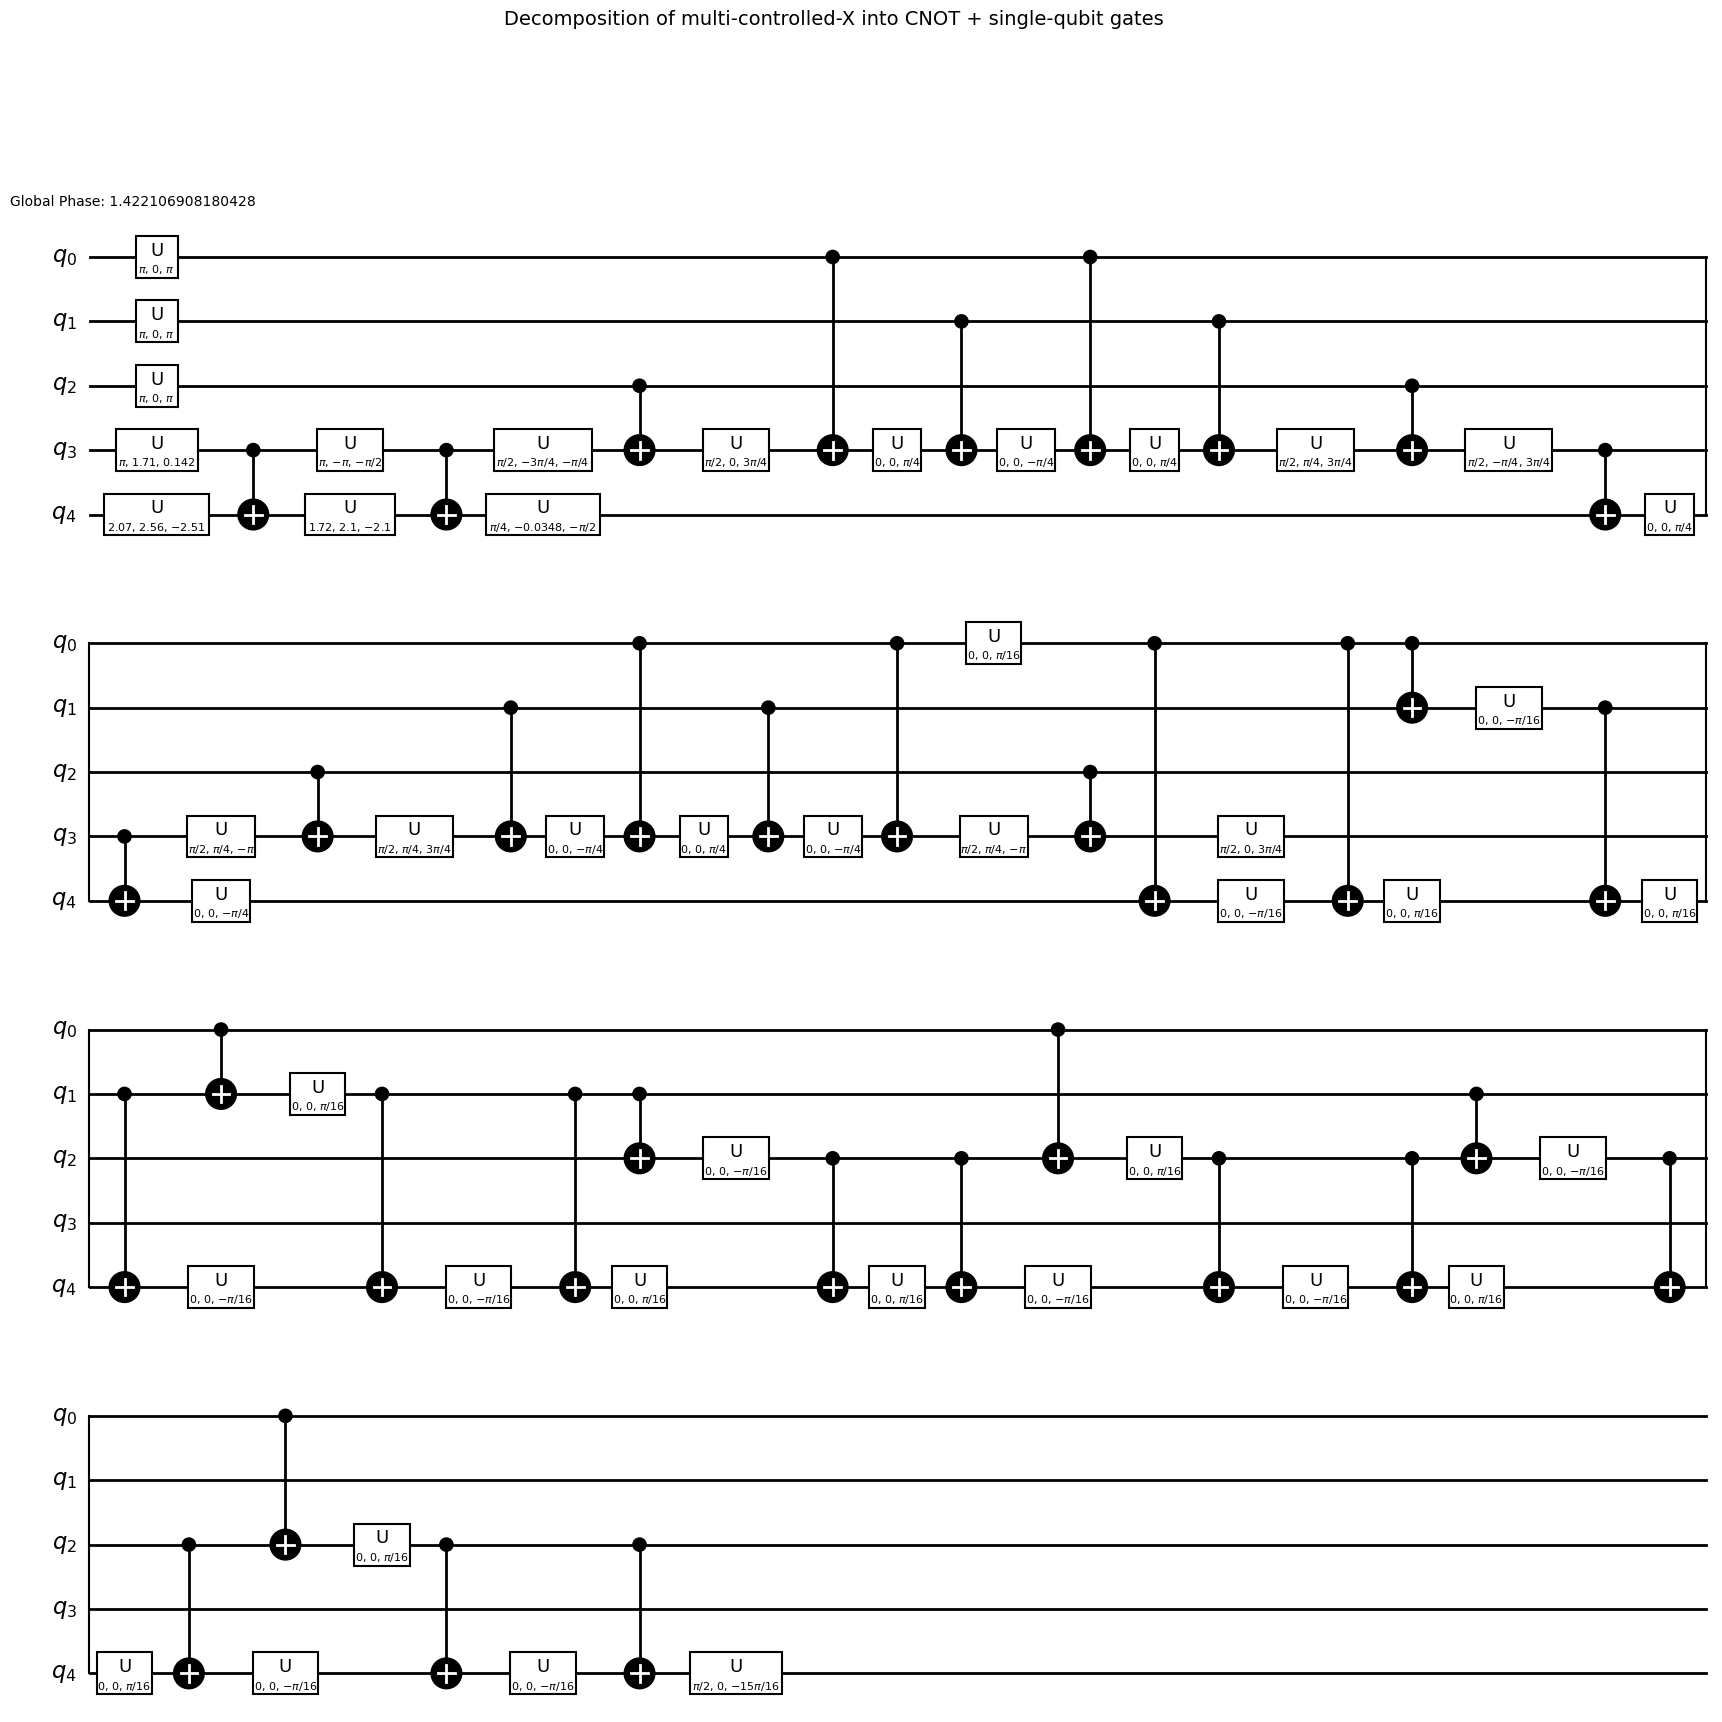

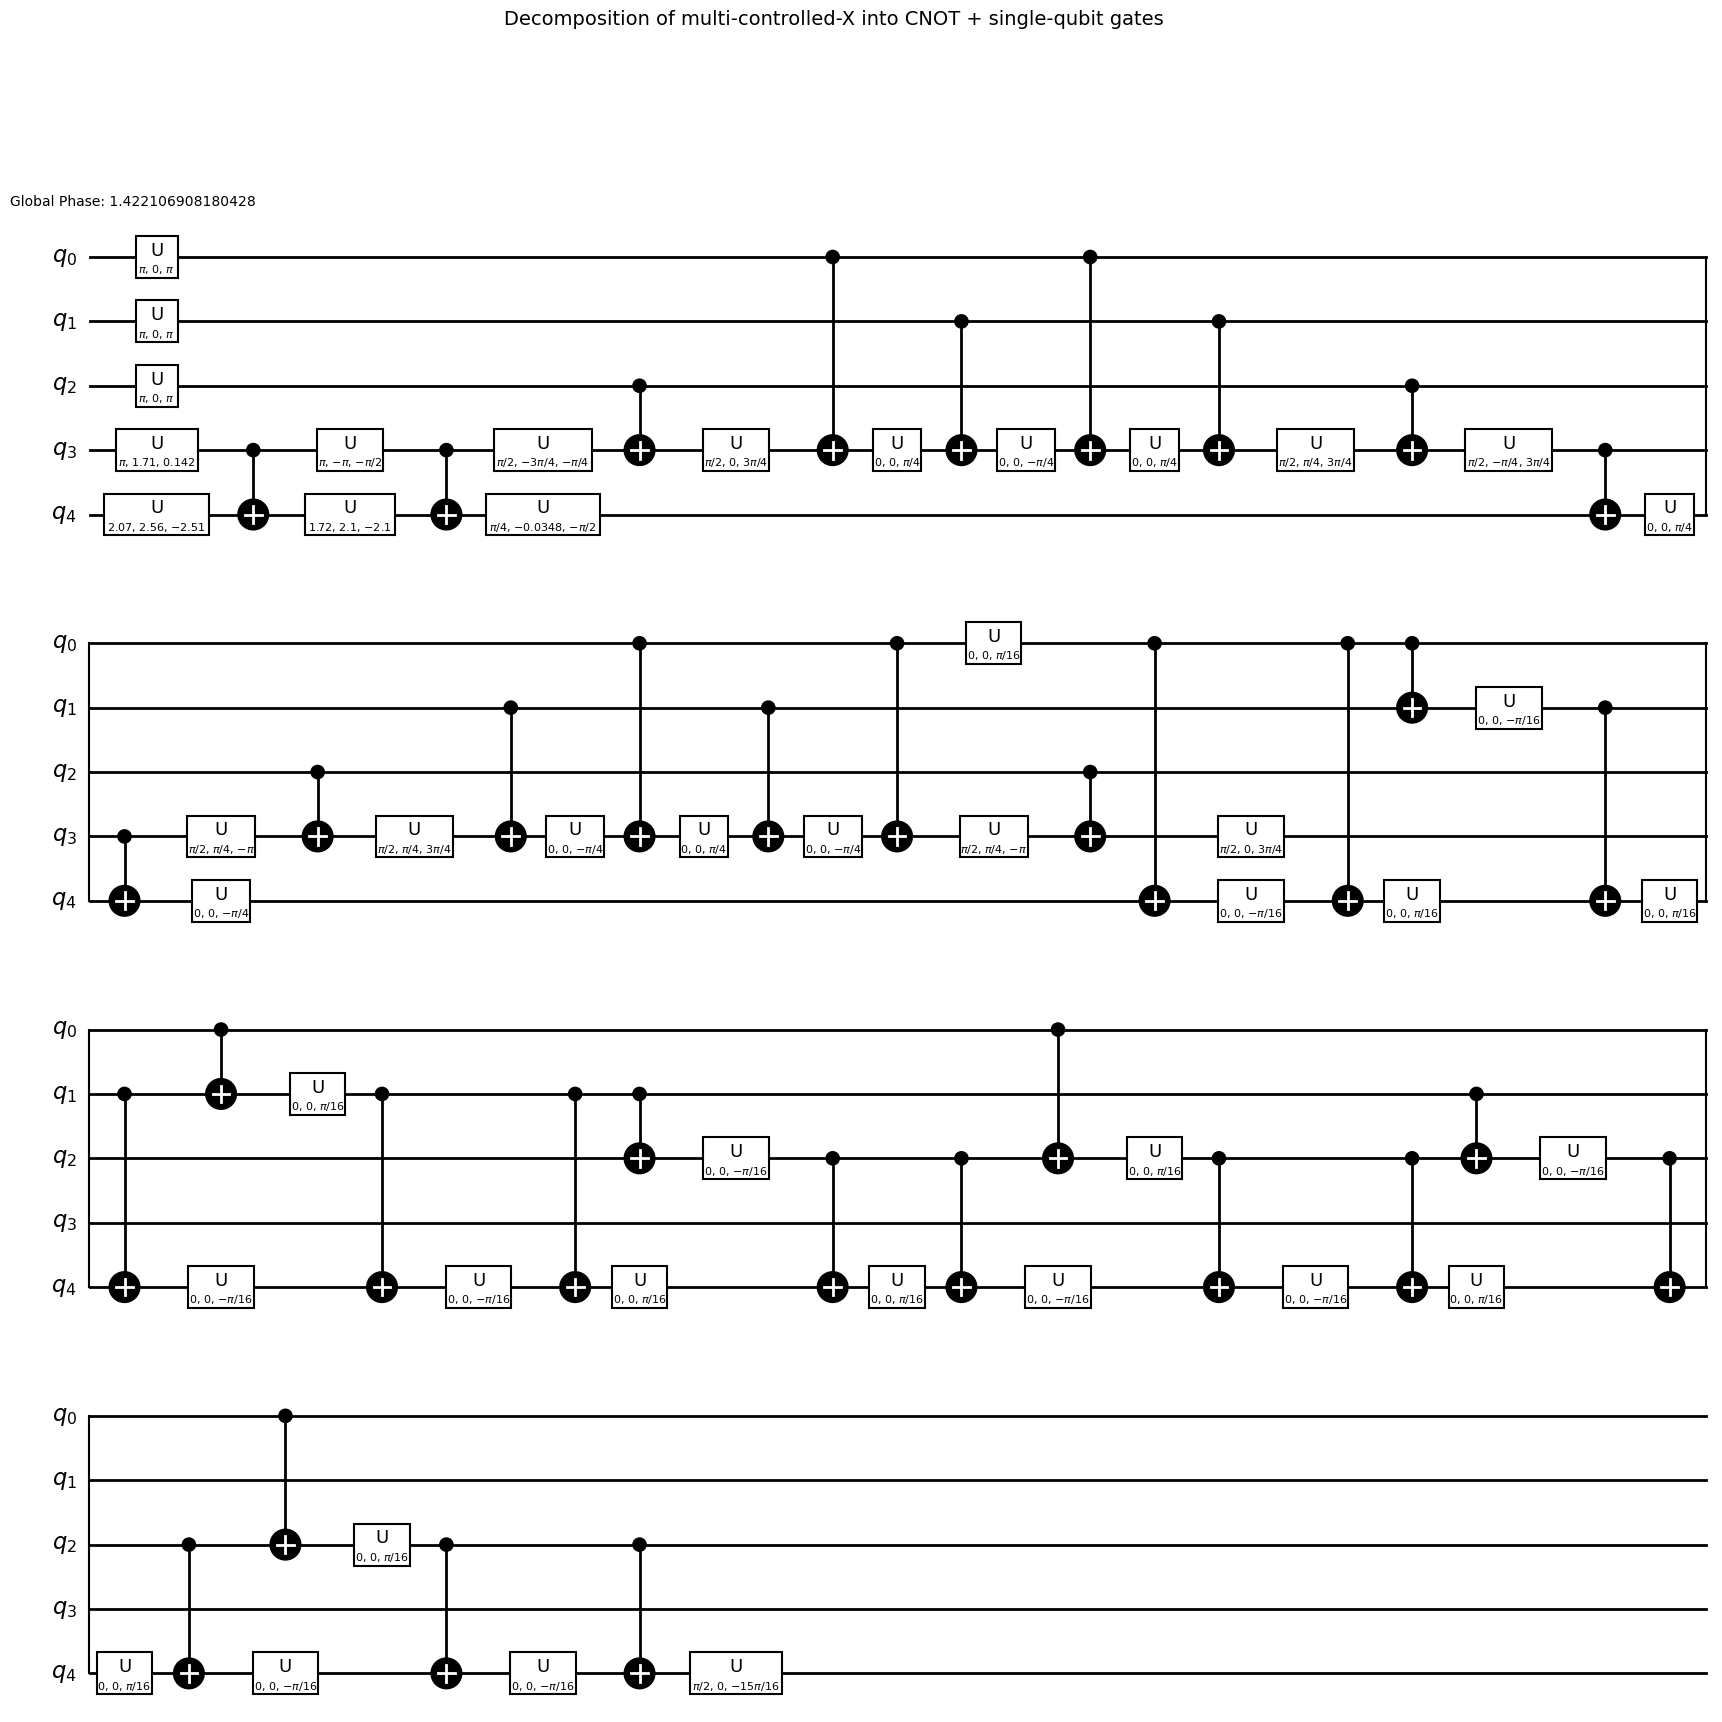

In [48]:
# Show the actual gate-level decomposition Qiskit uses internally
qc_mcx_decomp = transpile(qc_mcx, basis_gates=['u', 'cx'])
show_circuit(qc_mcx_decomp, 'Decomposition of multi-controlled-X into CNOT + single-qubit gates')

## 6. The Controlled-Phase Gate (Sec. 3.1.7) — Phase Kickback

A phase factor exp(i alpha) should appear ONLY when the control is |1> (Eq. 3.100). This is implemented with the **CP** gate. We visualize the classic **phase-kickback** experiment: put the control in superposition, apply CP, then interfere with a Hadamard and measure — the hidden phase becomes a visible probability shift.

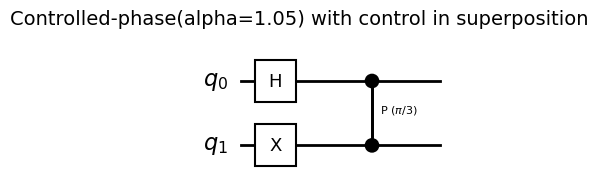

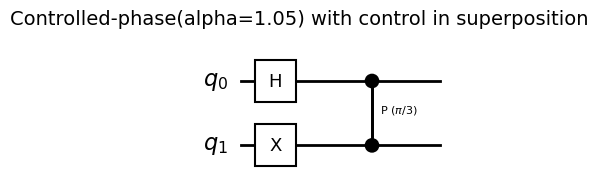

In [49]:
alpha = np.pi / 3
qc_cp = QuantumCircuit(2, name='controlled-phase')
qc_cp.h(0)
qc_cp.x(1)
qc_cp.cp(alpha, 0, 1)
show_circuit(qc_cp, f'Controlled-phase(alpha={alpha:.2f}) with control in superposition')

Measured relative phase between q0=0 and q0=1 components: 1.0471975511965976
Expected (Eq. 3.100 with a=1): 1.0471975511965976


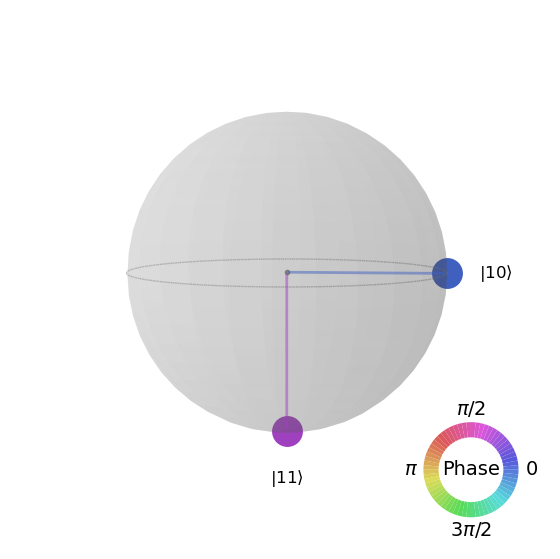

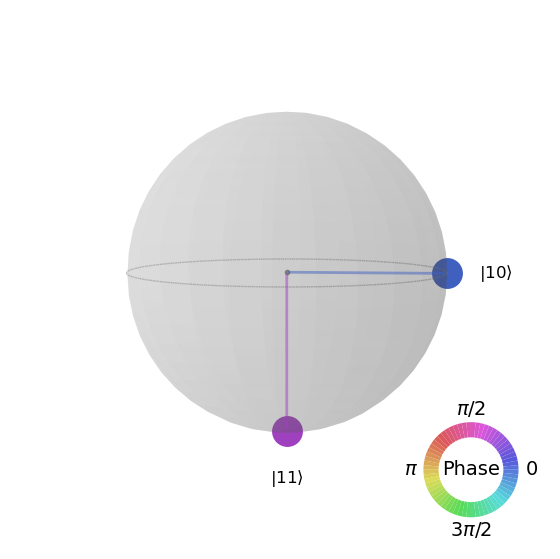

In [50]:
sv = Statevector(qc_cp)
amp_q0_0 = sv.data[2]
amp_q0_1 = sv.data[3]
measured_phase = np.angle(amp_q0_1) - np.angle(amp_q0_0)
print('Measured relative phase between q0=0 and q0=1 components:', measured_phase)
print('Expected (Eq. 3.100 with a=1):', alpha)
display(plot_state_qsphere(sv))

/opt/anaconda3/lib/python3.13/site-packages/qiskit/visualization/counts_visualization.py:306: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


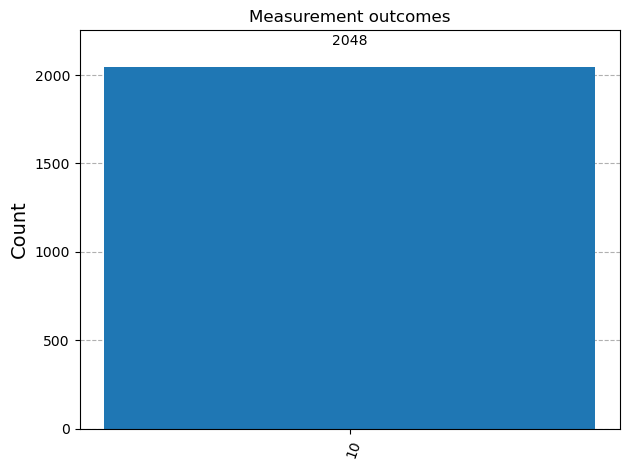

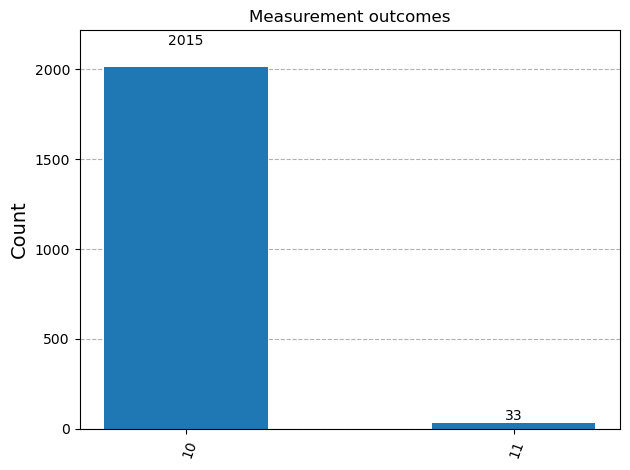

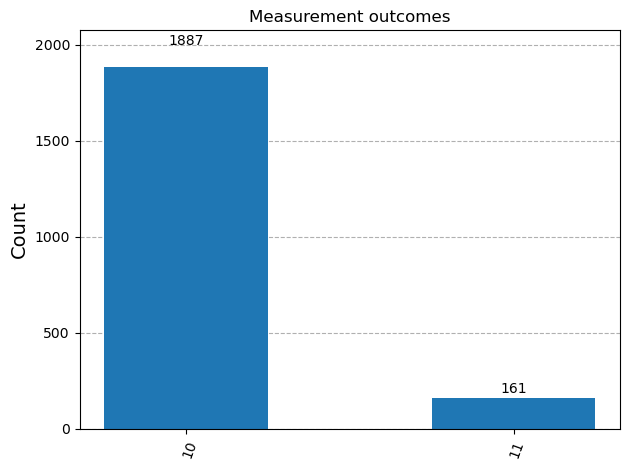

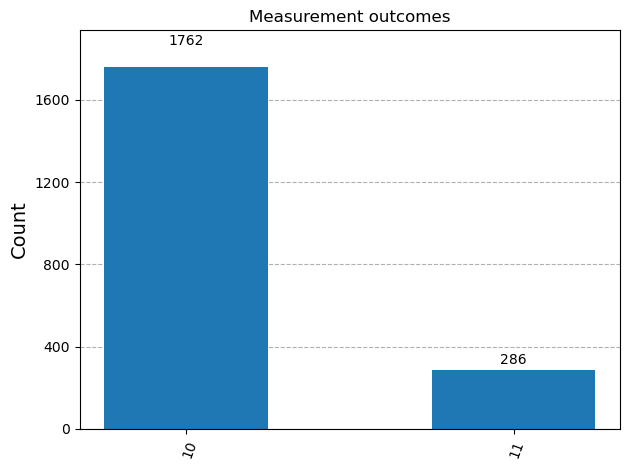

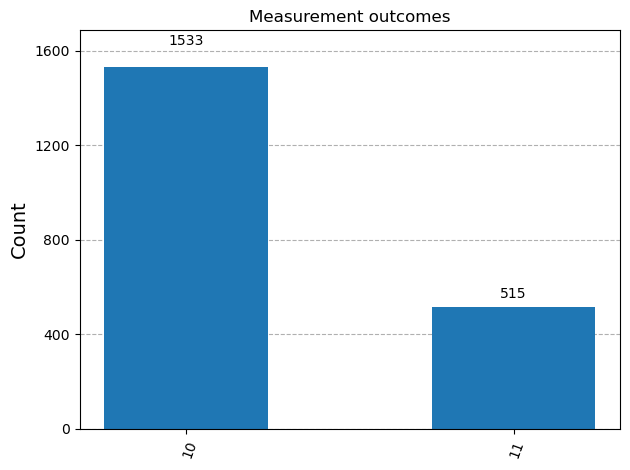

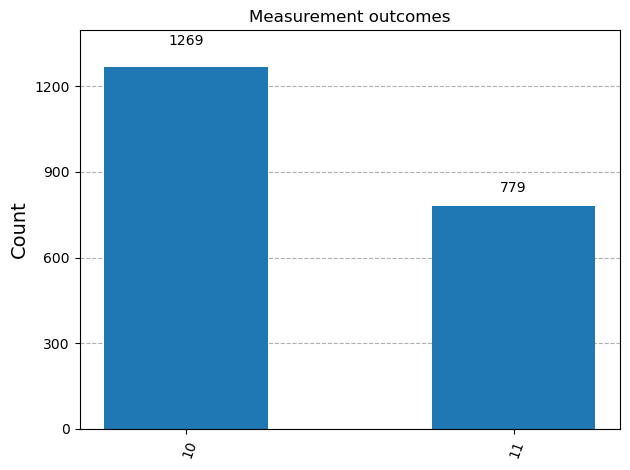

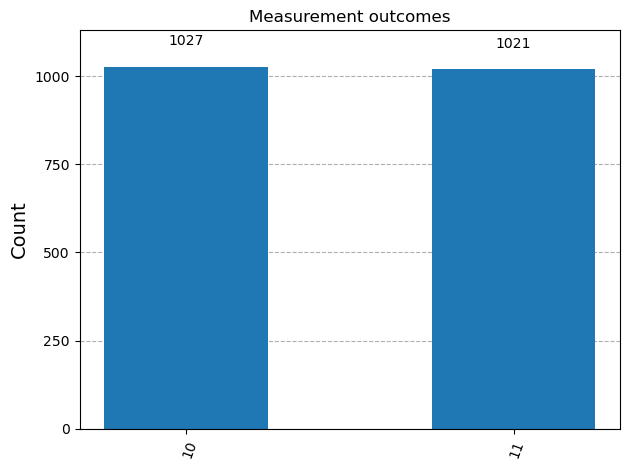

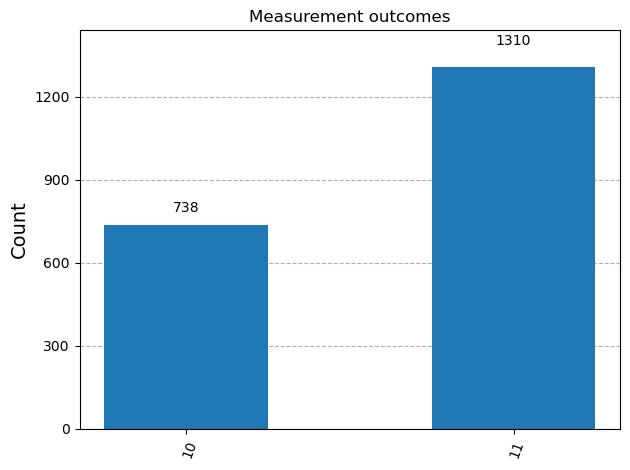

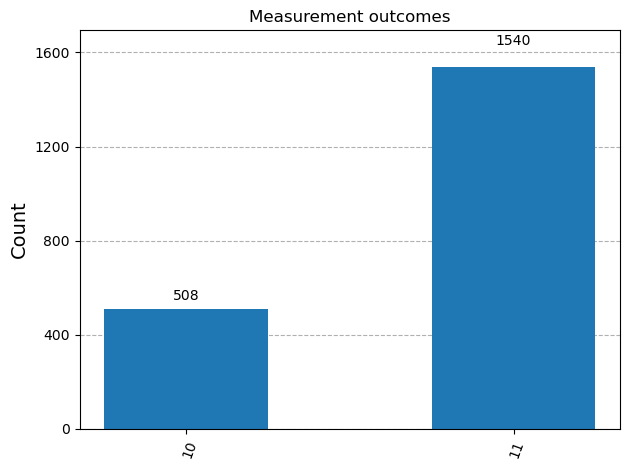

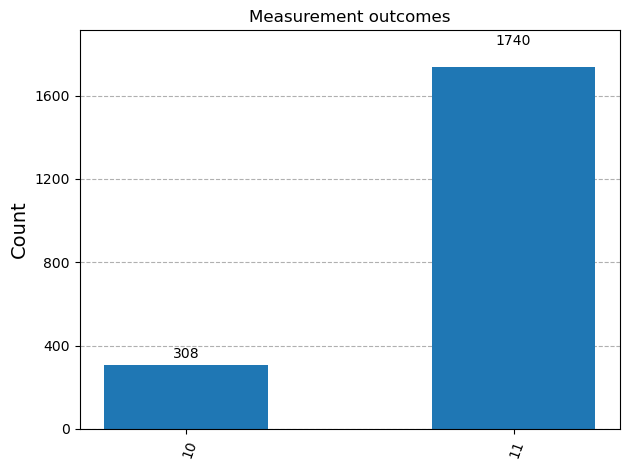

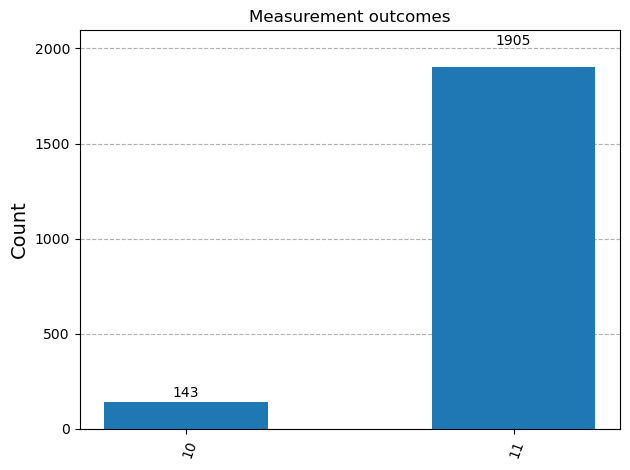

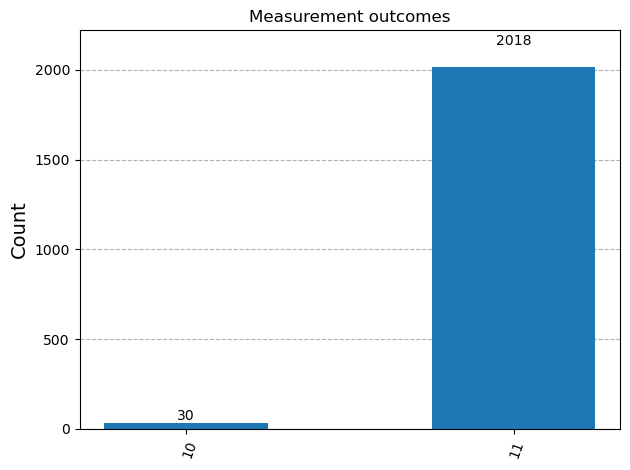

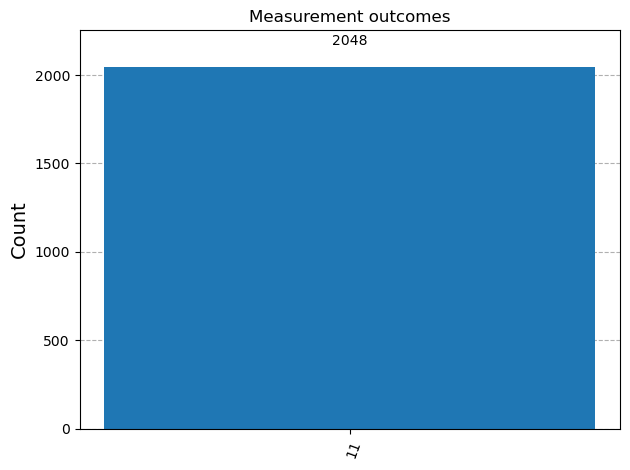

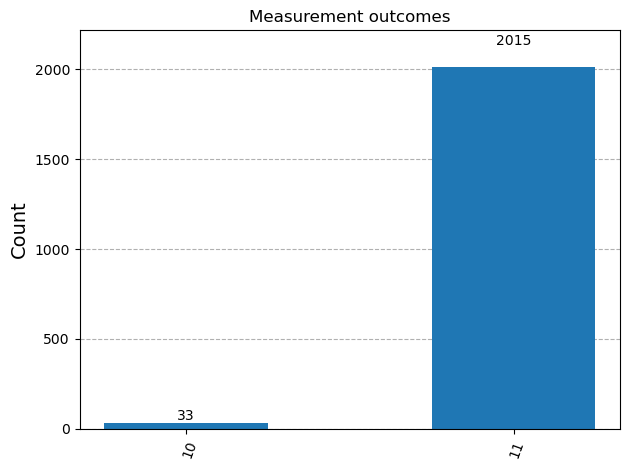

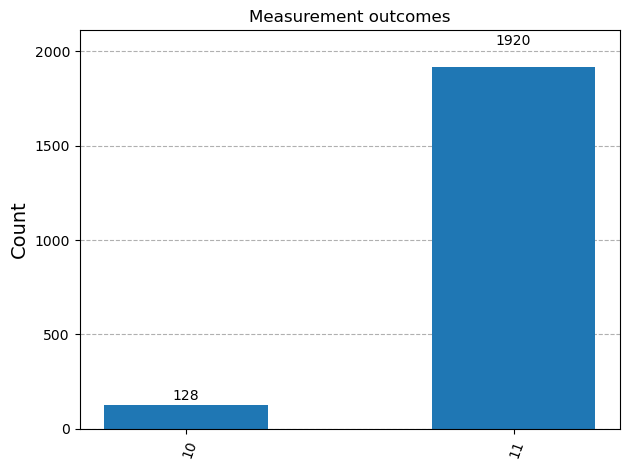

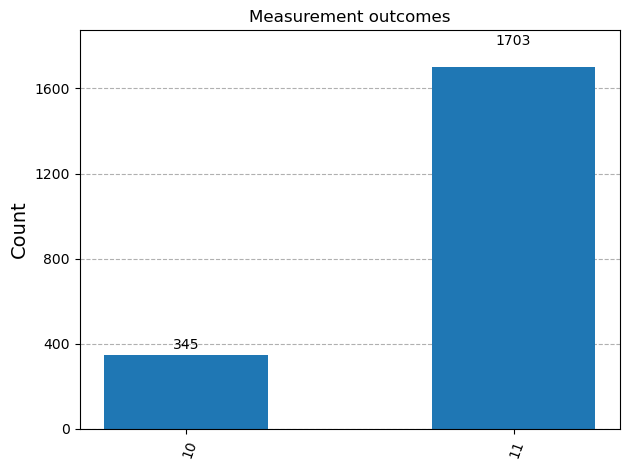

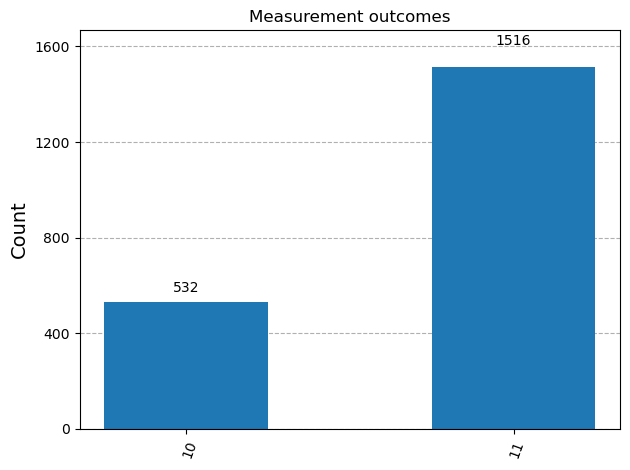

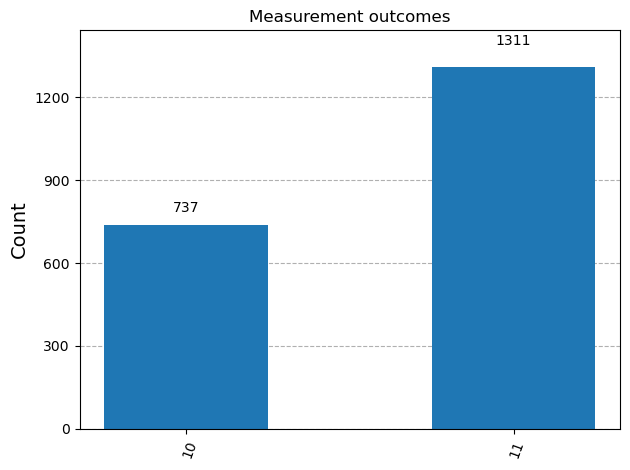

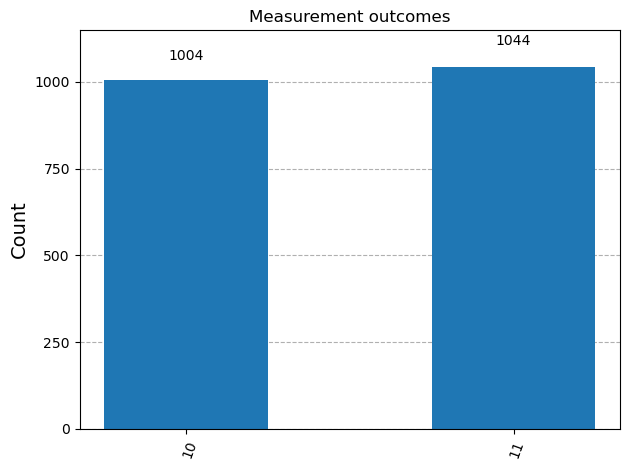

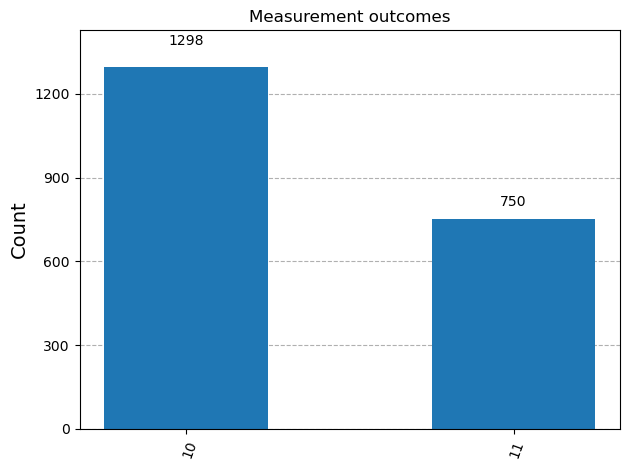

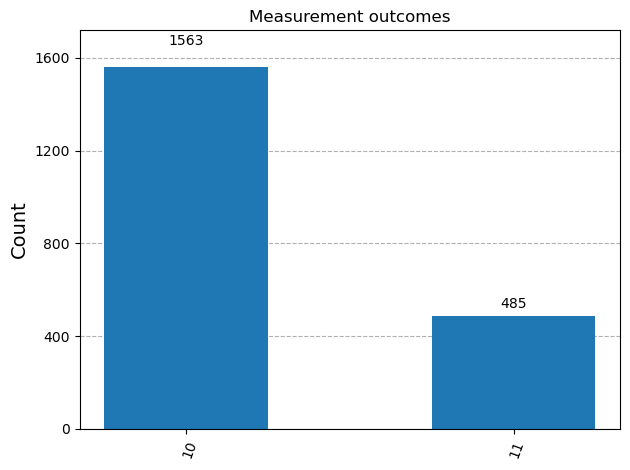

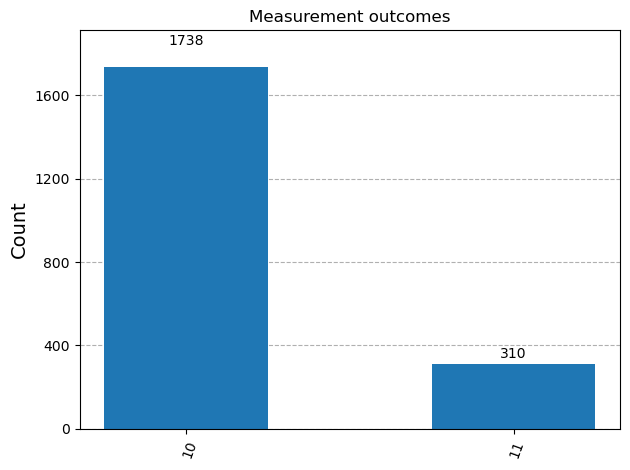

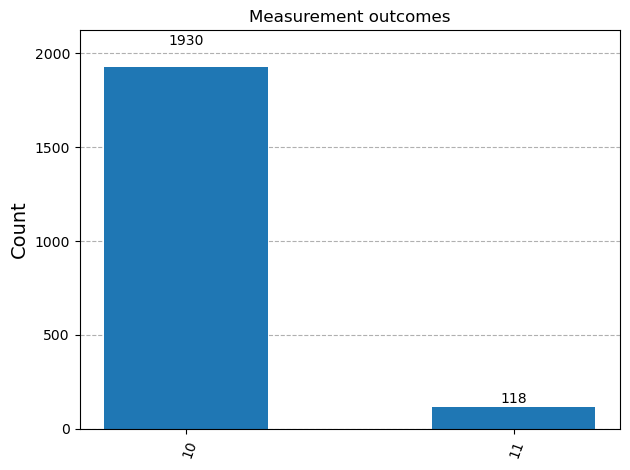

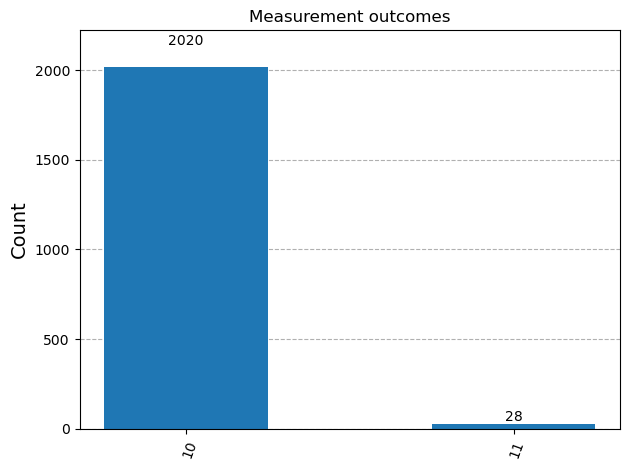

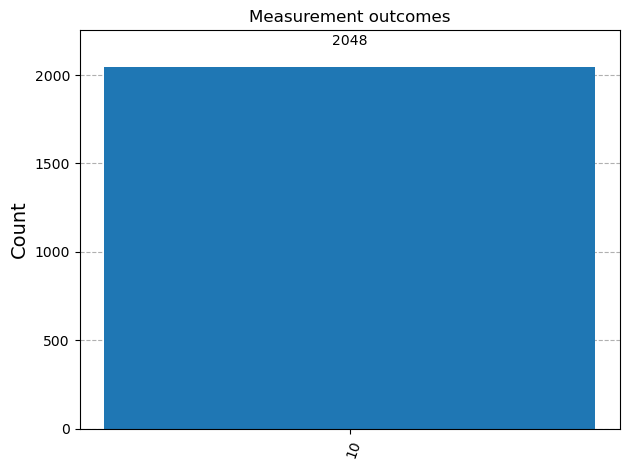

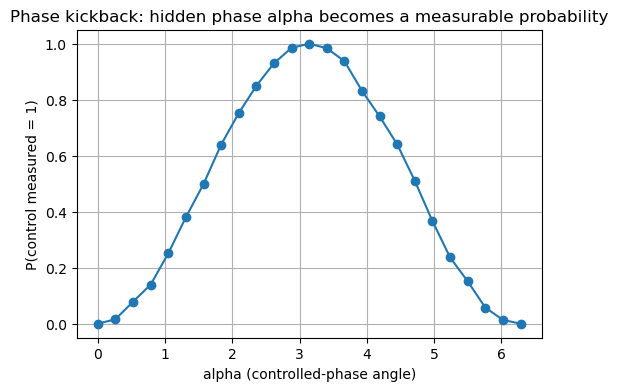

In [51]:
# Phase-kickback interference experiment: sweep alpha, apply H again on control, measure P(control=1)
if AER_AVAILABLE:
    alphas = np.linspace(0, 2*np.pi, 25)
    p1_list = []
    for a_ in alphas:
        qc_pk = QuantumCircuit(2)
        qc_pk.h(0)
        qc_pk.x(1)
        qc_pk.cp(a_, 0, 1)
        qc_pk.h(0)
        counts, _, _ = measure_and_plot(qc_pk, shots=2048)
        p1 = sum(v for k, v in counts.items() if k[-1] == '1') / 2048  # control is qubit0 -> last char
        p1_list.append(p1)
    plt.figure(figsize=(6,4))
    plt.plot(alphas, p1_list, 'o-')
    plt.xlabel('alpha (controlled-phase angle)')
    plt.ylabel('P(control measured = 1)')
    plt.title('Phase kickback: hidden phase alpha becomes a measurable probability')
    plt.grid(True)
    plt.show()

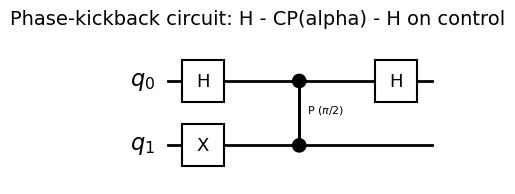

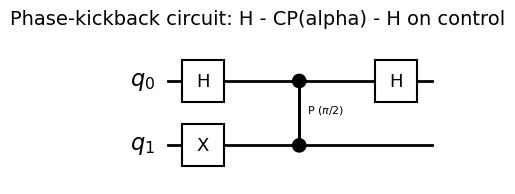

In [52]:
qc_pk_example = QuantumCircuit(2, name='phase kickback')
qc_pk_example.h(0)
qc_pk_example.x(1)
qc_pk_example.cp(np.pi/2, 0, 1)
qc_pk_example.h(0)
show_circuit(qc_pk_example, 'Phase-kickback circuit: H - CP(alpha) - H on control')

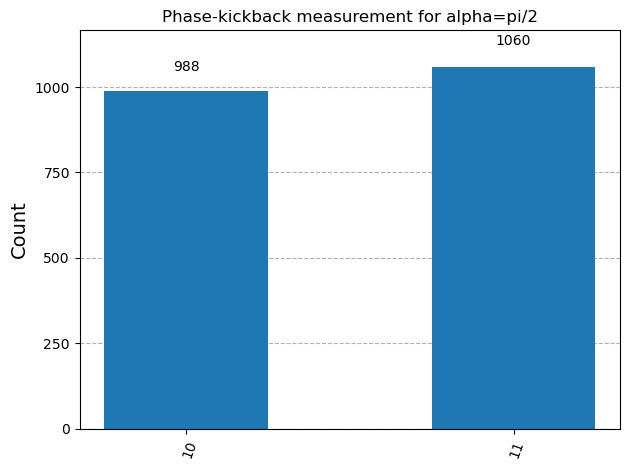

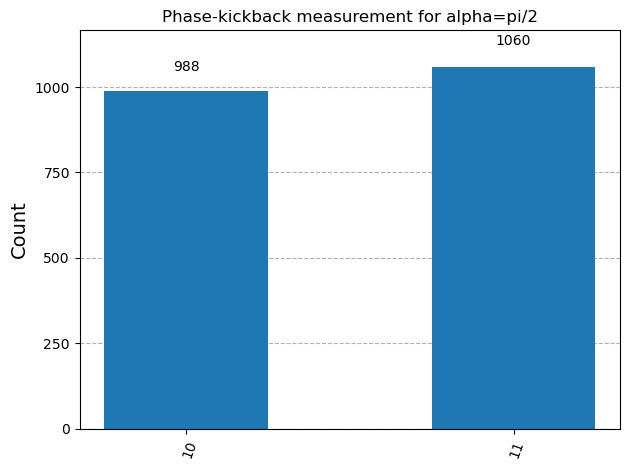

In [53]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_pk_example, title='Phase-kickback measurement for alpha=pi/2')
    display(fig)

## 7. The No-Cloning Theorem (Sec. 3.2)

No unitary can copy an arbitrary unknown state (Eq. 3.176-3.178). We test the most natural candidate 'cloning circuit' — a CNOT with the unknown state on the control and a blank ancilla |0> on the target — via **both** statevector fidelity **and** measurement statistics.

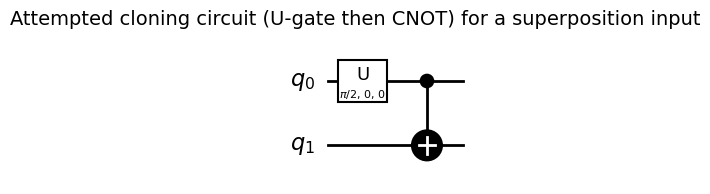

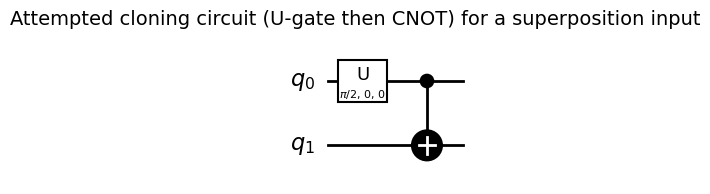

In [54]:
def attempted_clone_circuit(theta, phi):
    qc = QuantumCircuit(2, name='attempted clone')
    qc.u(theta, phi, 0, 0)
    qc.cx(0, 1)
    return qc

qc_clone_basis = attempted_clone_circuit(0.0, 0.0)      # theta=0 -> |0> input, should clone perfectly
qc_clone_super = attempted_clone_circuit(np.pi/2, 0.0)   # theta=pi/2 -> |+> input, should FAIL to clone

show_circuit(qc_clone_super, 'Attempted cloning circuit (U-gate then CNOT) for a superposition input')

In [55]:
def ideal_clone(theta, phi):
    single = QuantumCircuit(1)
    single.u(theta, phi, 0, 0)
    psi = Statevector(single)
    return psi.tensor(psi)

print('theta      fidelity with ideal clone |psi>|psi>')
for th in np.linspace(0, np.pi, 7):
    actual = Statevector(attempted_clone_circuit(th, 0.0))
    ideal = ideal_clone(th, 0.0)
    fid = state_fidelity(actual, ideal)
    print(f'{th:6.3f}       {fid:6.3f}')

theta      fidelity with ideal clone |psi>|psi>
 0.000        1.000
 0.524        0.844
 1.047        0.600
 1.571        0.500
 2.094        0.600
 2.618        0.844
 3.142        1.000


Now the **measurement** view: for the basis-state input (theta=0) the two qubits are always perfectly correlated (looks like cloning). For the superposition input (theta=pi/2, state |+>) the CNOT instead creates a **Bell-like entangled state** — individually each qubit is 50/50, and they are correlated, but neither qubit alone equals the original |+> state (no clone exists).

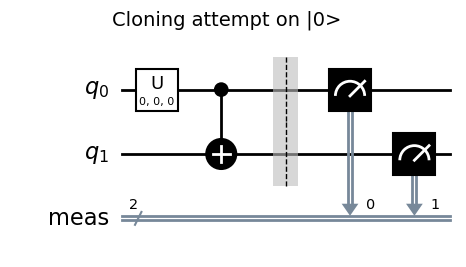

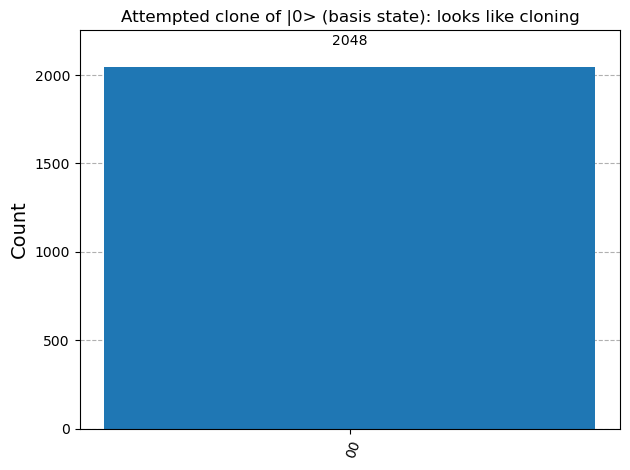

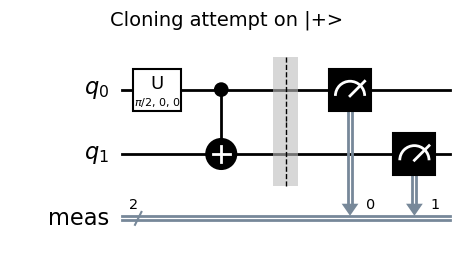

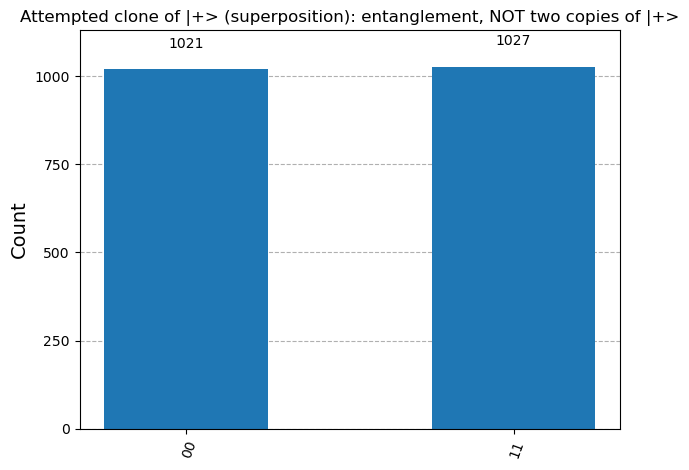

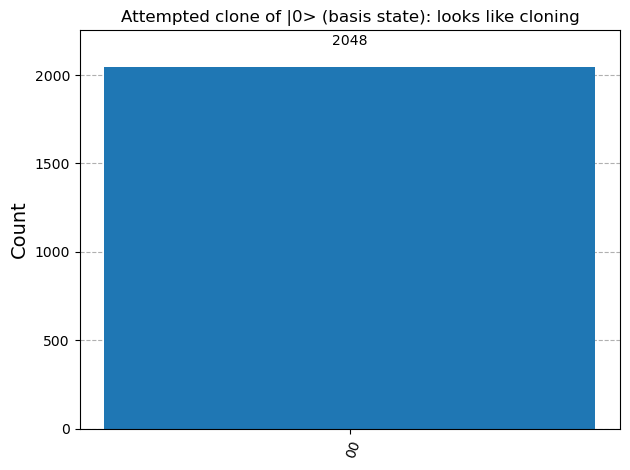

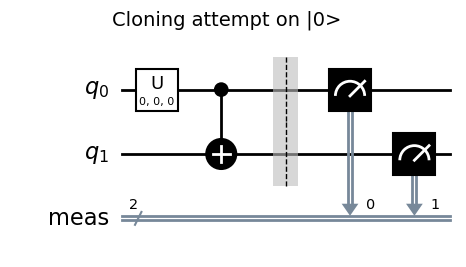

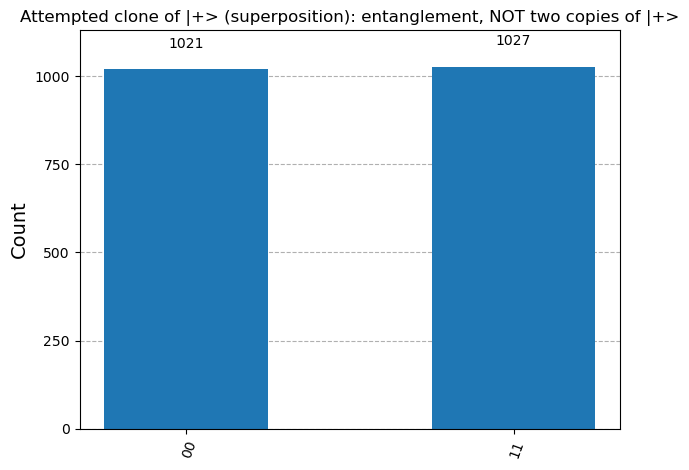

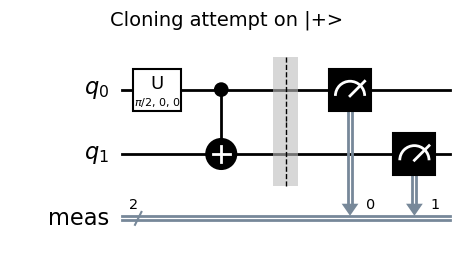

In [56]:
if AER_AVAILABLE:
    counts_basis, fig_basis, qcm_basis = measure_and_plot(qc_clone_basis, shots=2048,
                                                            title='Attempted clone of |0> (basis state): looks like cloning')
    display(show_circuit(qcm_basis, 'Cloning attempt on |0>'))
    display(fig_basis)

    counts_super, fig_super, qcm_super = measure_and_plot(qc_clone_super, shots=2048,
                                                            title='Attempted clone of |+> (superposition): entanglement, NOT two copies of |+>')
    display(show_circuit(qcm_super, 'Cloning attempt on |+>'))
    display(fig_super)

**Key check:** if cloning had worked, measuring EACH qubit alone in the X-basis (apply H before measuring) should give |+> with certainty. Let's test that directly.

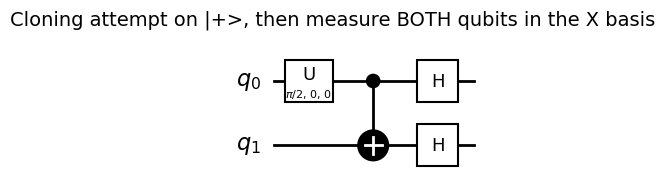

In [57]:
if AER_AVAILABLE:
    qc_clone_xbasis = attempted_clone_circuit(np.pi/2, 0.0)
    qc_clone_xbasis.h(0)
    qc_clone_xbasis.h(1)
    show_circuit(qc_clone_xbasis, 'Cloning attempt on |+>, then measure BOTH qubits in the X basis')

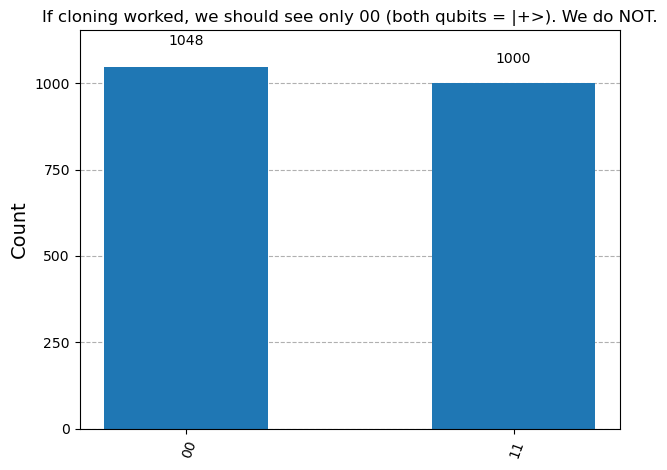

Counts: {'11': 1000, '00': 1048}


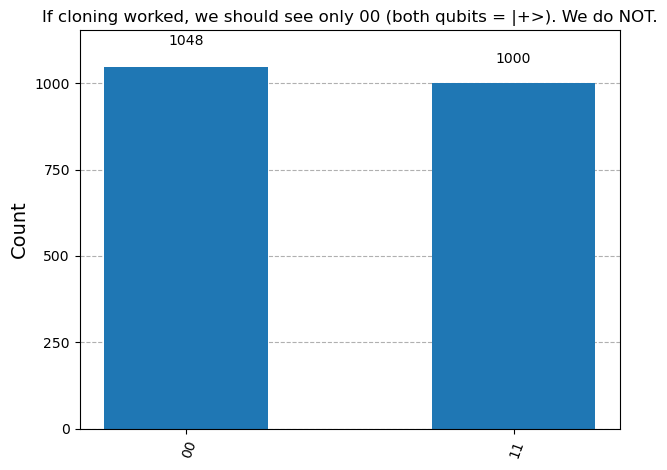

In [58]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_clone_xbasis, shots=2048,
                                         title='If cloning worked, we should see only 00 (both qubits = |+>). We do NOT.')
    display(fig)
    print('Counts:', counts)

The histogram shows a spread across outcomes, not a clean spike at `00` — direct experimental confirmation of the no-cloning theorem (Eq. 3.178).

## 8. Bonus: Deutsch's Algorithm (Sec. 4.1.1) — Full Circuits + Measurements

Oracle: Uf|x>|y> = |x>|y XOR f(x)> (Eq. 4.9). We build the circuit of Fig. 4.1 for all four possible single-bit functions, draw each circuit, and measure qubit 0 to decide constant vs. balanced with a SINGLE query.

In [59]:
def deutsch_oracle(kind):
    qc = QuantumCircuit(2, name=f'Uf_{kind}')
    if kind == 'balanced_identity':
        qc.cx(0, 1)
    elif kind == 'balanced_not':
        qc.cx(0, 1)
        qc.x(1)
    elif kind == 'constant_1':
        qc.x(1)
    return qc

def deutsch_circuit(kind):
    qc = QuantumCircuit(2, 1, name=f'Deutsch[{kind}]')
    qc.x(1)
    qc.h(0)
    qc.h(1)
    qc.barrier()
    qc.append(deutsch_oracle(kind).to_gate(label=f'Uf[{kind}]'), [0, 1])
    qc.barrier()
    qc.h(0)
    qc.measure(0, 0)
    return qc

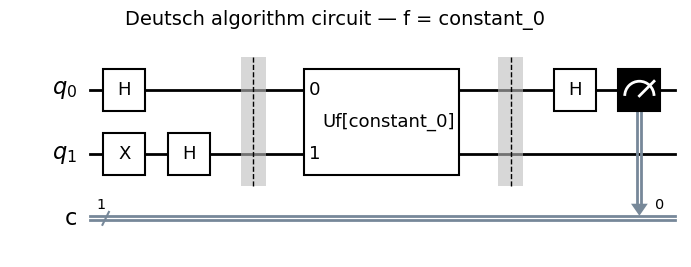

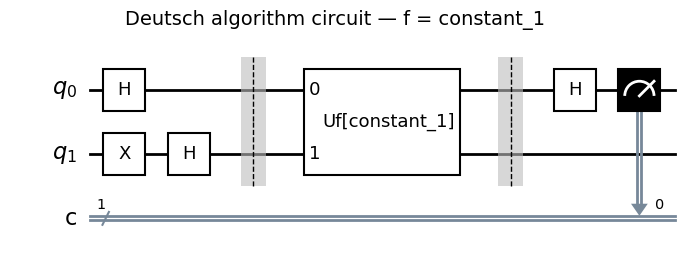

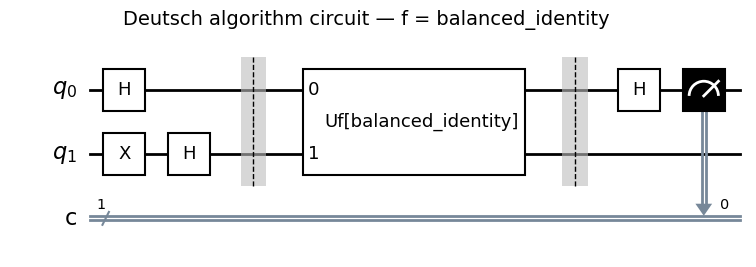

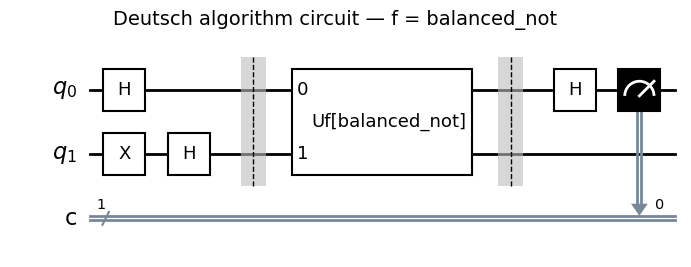

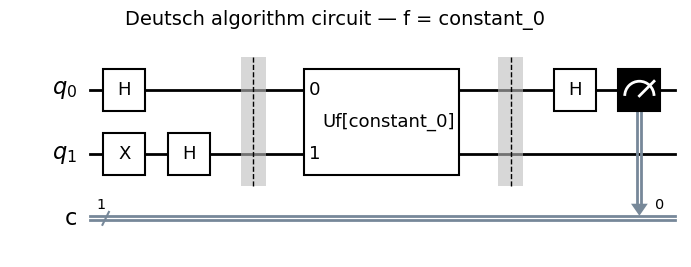

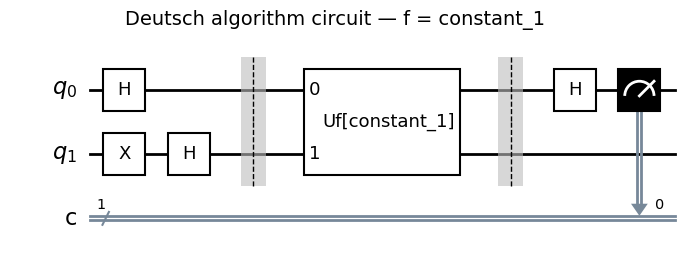

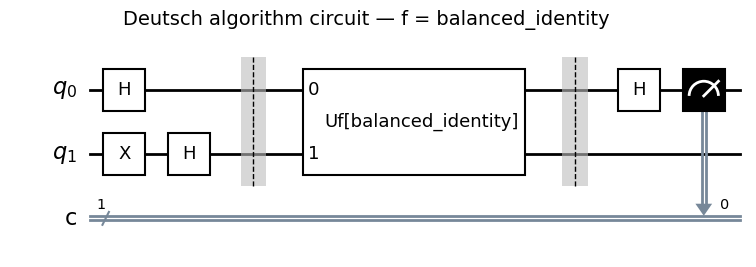

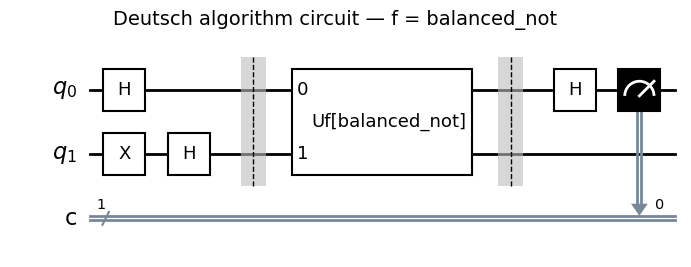

In [60]:
for kind in ['constant_0', 'constant_1', 'balanced_identity', 'balanced_not']:
    qc_d = deutsch_circuit(kind)
    display(show_circuit(qc_d, f'Deutsch algorithm circuit — f = {kind}'))

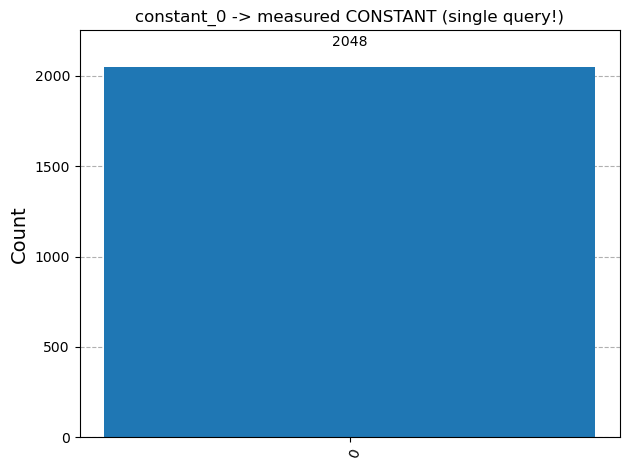

constant_0 -> {'0': 2048} -> CONSTANT


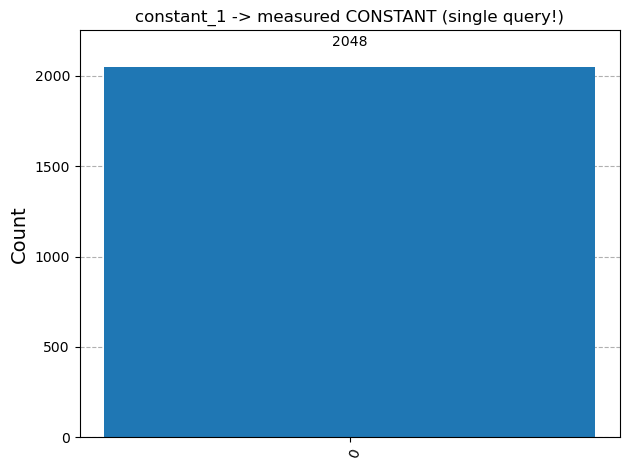

constant_1 -> {'0': 2048} -> CONSTANT


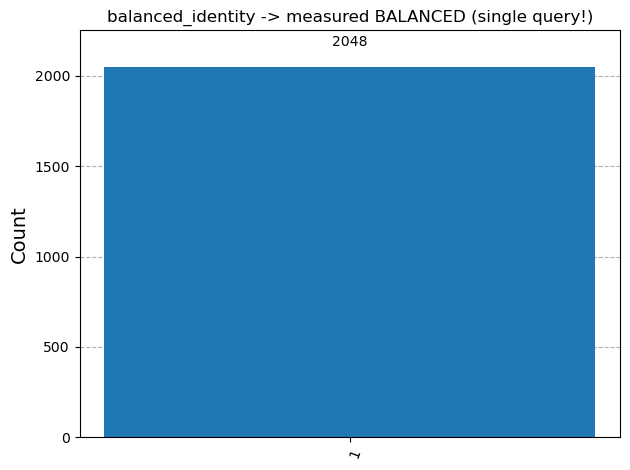

balanced_identity -> {'1': 2048} -> BALANCED


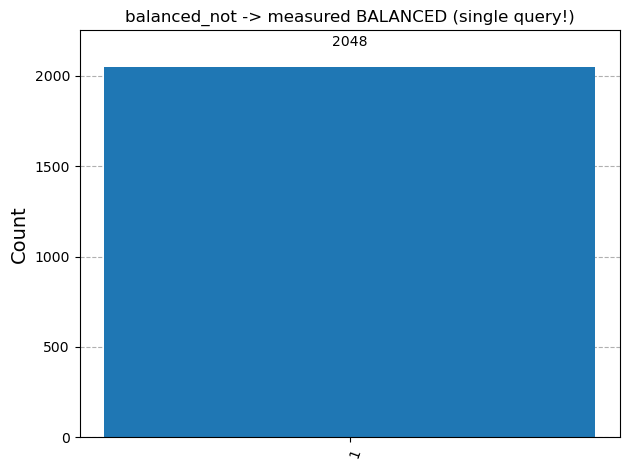

balanced_not -> {'1': 2048} -> BALANCED


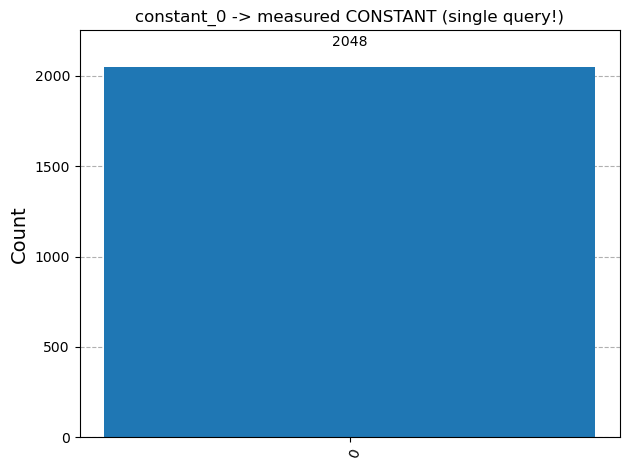

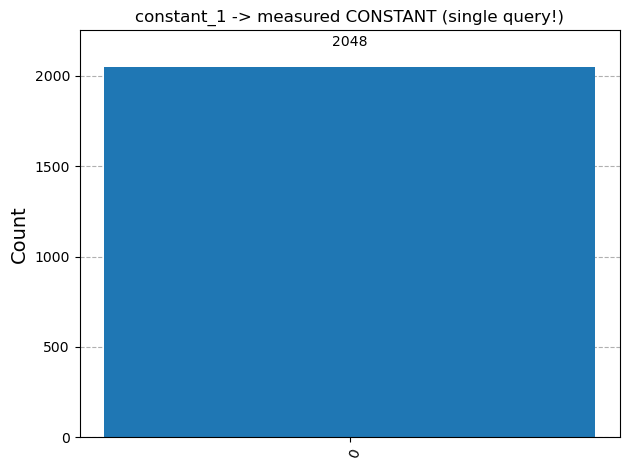

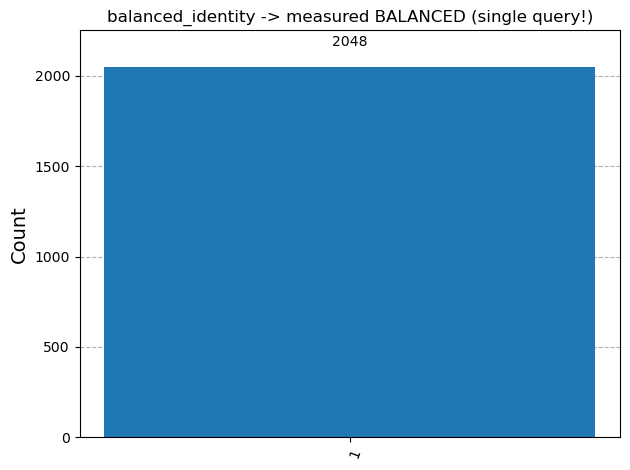

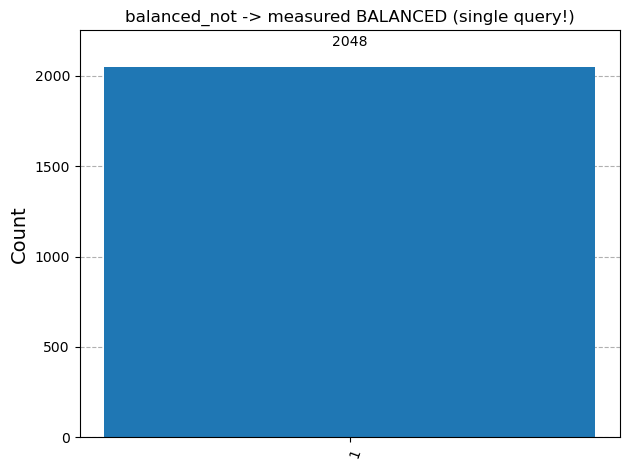

In [61]:
if AER_AVAILABLE:
    for kind in ['constant_0', 'constant_1', 'balanced_identity', 'balanced_not']:
        qc_d = deutsch_circuit(kind)
        tqc = transpile(qc_d, BACKEND)
        result = BACKEND.run(tqc, shots=2048).result()
        counts = result.get_counts()
        verdict = 'CONSTANT' if '0' in counts and counts.get('0', 0) > counts.get('1', 0) else 'BALANCED'
        display(plot_histogram(counts, title=f'{kind} -> measured {verdict} (single query!)'))
        print(kind, '->', counts, '->', verdict)

This matches Eq. 4.12 (constant => qubit measured in |0>) and Eq. 4.14 (balanced => qubit measured in |1>) — obtained with a **single** oracle query, versus up to N/2+1 classical queries in general.

## 9. Bonus: The Quantum Fourier Transform Circuit (Sec. 4.6)

Built purely from H gates and controlled-phase gates R_k (Eq. 4.70 – 4.90, Fig. 4.4). We draw the circuit, verify it matches Qiskit's library QFT, visualize the output amplitudes, and run a period-finding style measurement (cf. Sec. 4.3 example).

/var/folders/mz/8z6t7nxj1rzg2jvg9_6hk8km0000gn/T/ipykernel_69355/3768370769.py:14: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_lib = QFT(n)


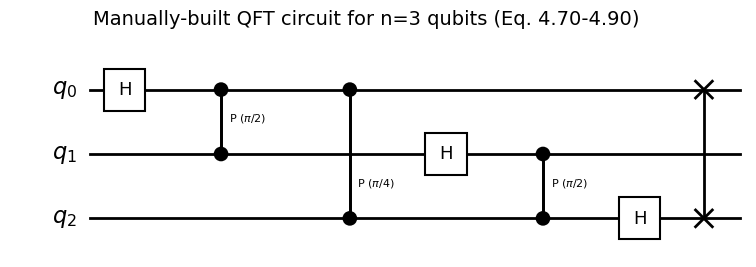

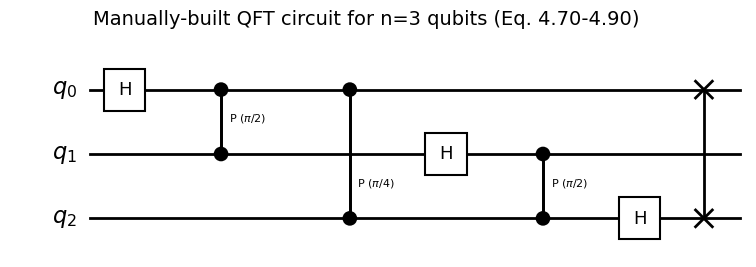

In [62]:
def qft_manual(n):
    qc = QuantumCircuit(n, name='QFT (manual)')
    for j in range(n):
        qc.h(j)
        for k in range(j + 1, n):
            angle = 2 * np.pi / (2 ** (k - j + 1))
            qc.cp(angle, k, j)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    return qc

n = 3
qc_manual = qft_manual(n)
qc_lib = QFT(n)
show_circuit(qc_manual, f'Manually-built QFT circuit for n={n} qubits (Eq. 4.70-4.90)')

Manual QFT matches Qiskit library QFT: False


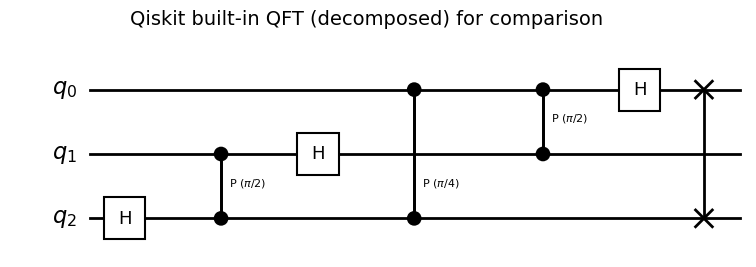

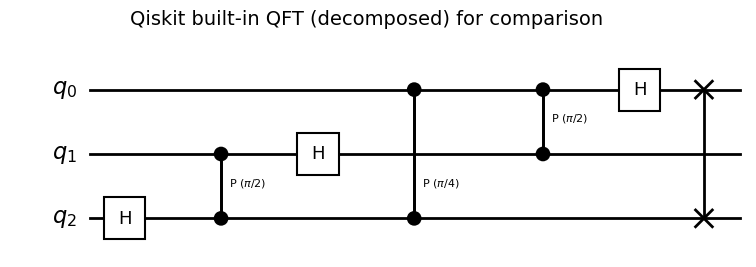

In [63]:
print('Manual QFT matches Qiskit library QFT:', np.allclose(Operator(qc_manual).data, Operator(qc_lib).data))
show_circuit(qc_lib.decompose(), 'Qiskit built-in QFT (decomposed) for comparison')

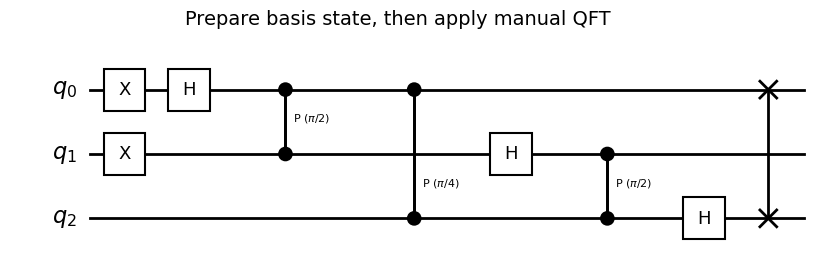

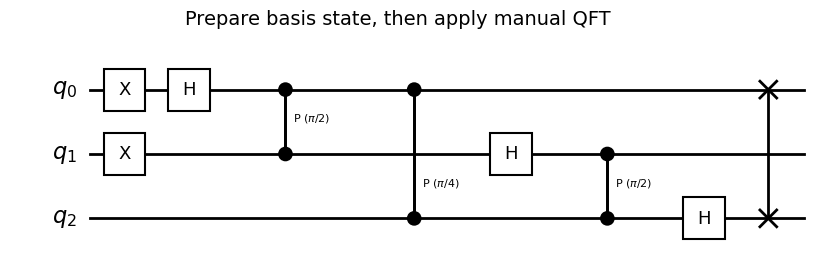

In [64]:
# Apply QFT to a computational basis state |x=3> and visualize output amplitudes
qc_qft_input = QuantumCircuit(n)
qc_qft_input.x(0)  # sets |x> = |...011> depending on bit ordering; illustrative only
qc_qft_input.x(1)
qc_qft_full = qc_qft_input.compose(qc_manual)
show_circuit(qc_qft_full, 'Prepare basis state, then apply manual QFT')

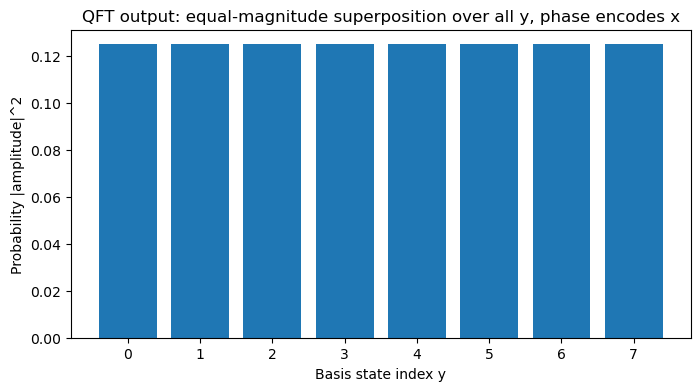

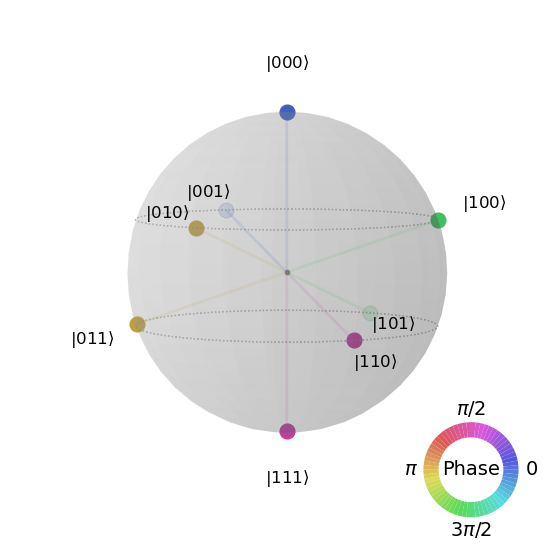

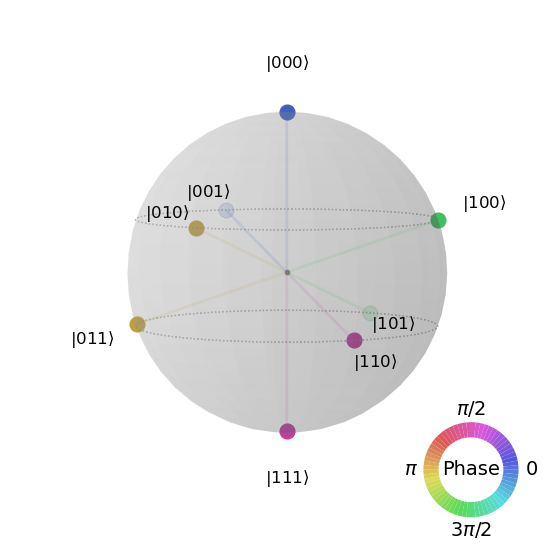

In [65]:
sv_qft = Statevector(qc_qft_full)
amps = sv_qft.data
plt.figure(figsize=(8,4))
plt.bar(range(len(amps)), np.abs(amps)**2)
plt.xlabel('Basis state index y')
plt.ylabel('Probability |amplitude|^2')
plt.title('QFT output: equal-magnitude superposition over all y, phase encodes x')
plt.show()
display(plot_state_qsphere(sv_qft))

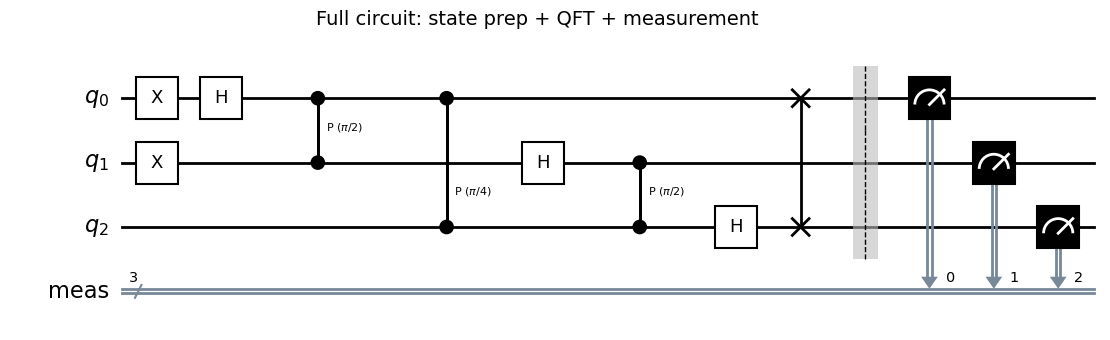

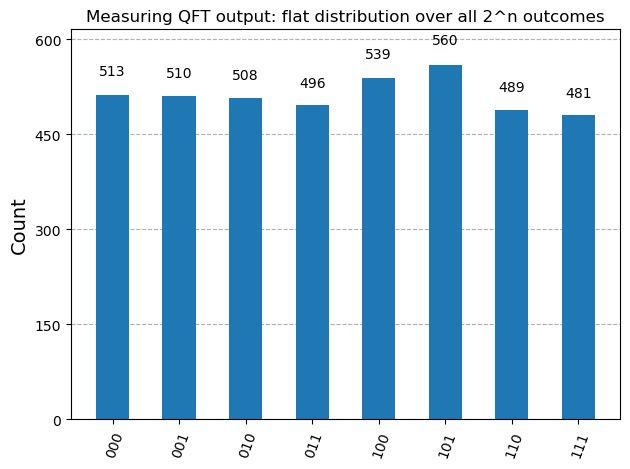

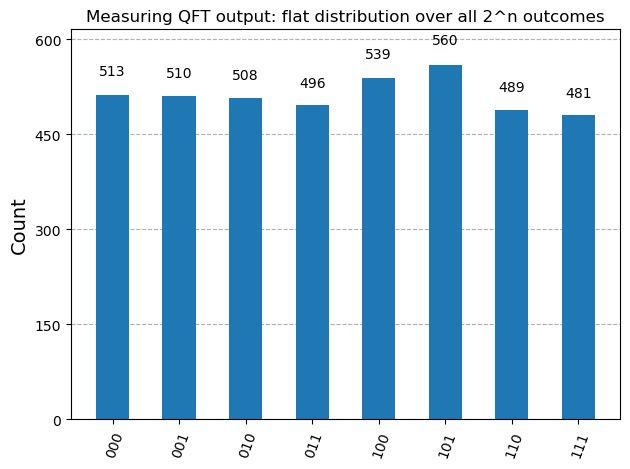

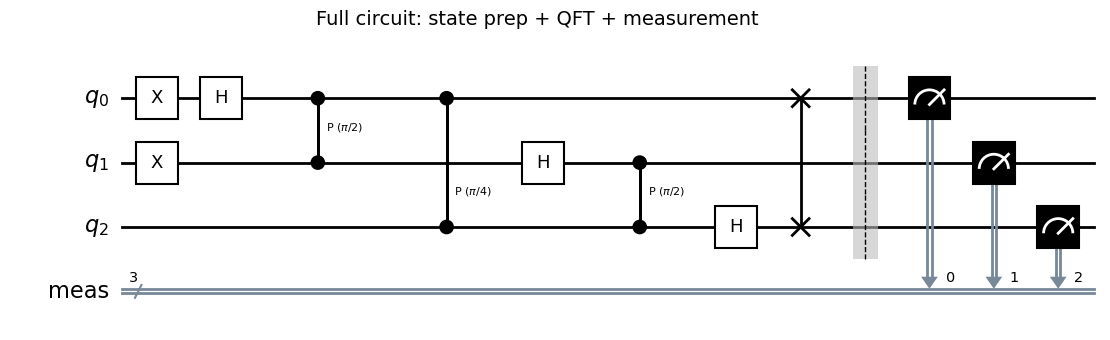

In [66]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_qft_full, shots=4096, title='Measuring QFT output: flat distribution over all 2^n outcomes')
    display(show_circuit(qcm, 'Full circuit: state prep + QFT + measurement'))
    display(fig)

### Period-finding style demonstration (cf. Sec. 4.3 example, Eq. 4.46-4.49)

We replicate the worked example of Sec. 4.3.1: a periodic function with period P=2 on n=3 bits, showing that measuring the QFT output peaks only at multiples of N/P.

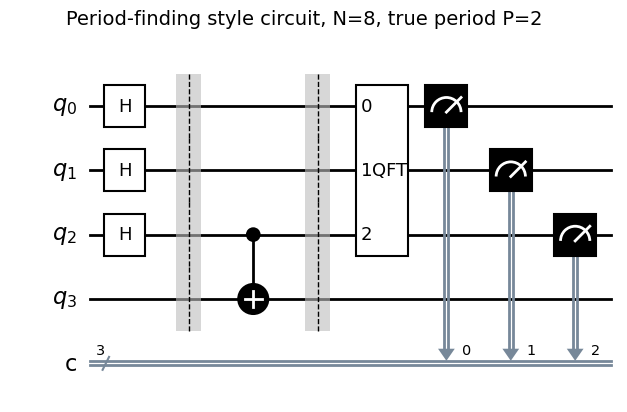

In [67]:
if AER_AVAILABLE:
    n_bits = 3
    N = 2 ** n_bits
    P = 2  # period, matches the worked example in Sec. 4.3.1

    def f_periodic(x):
        return x % P

    qc_period = QuantumCircuit(n_bits + 1, n_bits)
    qc_period.h(range(n_bits))
    qc_period.barrier()
    # naive oracle: copy parity of x into ancilla when f(x) changes (illustrative, matches period-2 example)
    qc_period.cx(n_bits - 1, n_bits)
    qc_period.barrier()
    qc_period.append(qft_manual(n_bits).to_gate(label='QFT'), range(n_bits))
    qc_period.measure(range(n_bits), range(n_bits))
    show_circuit(qc_period, f'Period-finding style circuit, N={N}, true period P={P}')

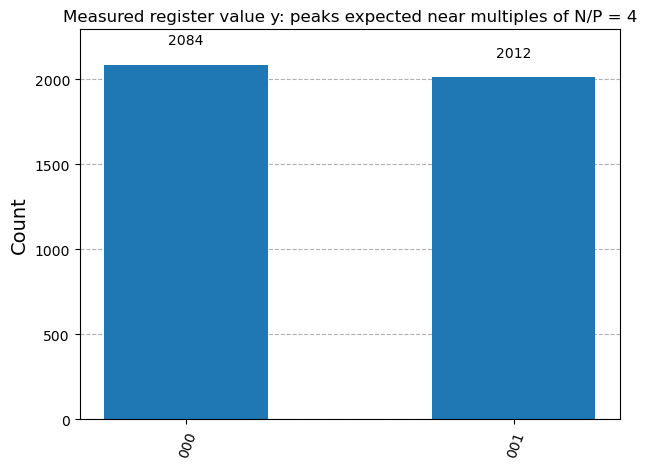

Counts: {'000': 2084, '001': 2012}
Compare with theory (Eq. 4.48): peaks should appear at y = 0 and y = N/2 = 4


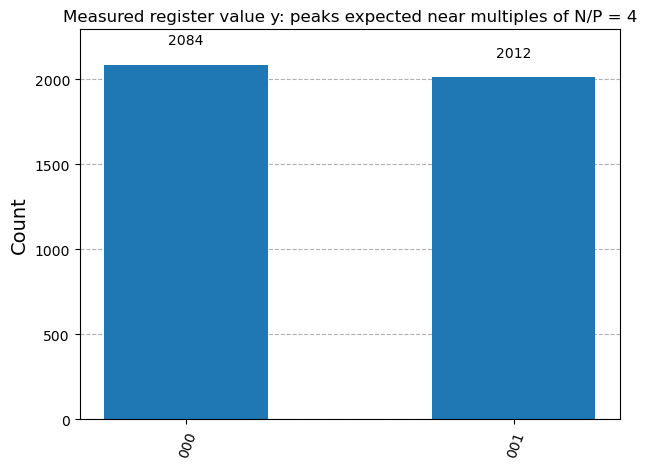

In [68]:
if AER_AVAILABLE:
    tqc = transpile(qc_period, BACKEND)
    result = BACKEND.run(tqc, shots=4096).result()
    counts = result.get_counts()
    display(plot_histogram(counts, title=f'Measured register value y: peaks expected near multiples of N/P = {N//P}'))
    print('Counts:', counts)
    print('Compare with theory (Eq. 4.48): peaks should appear at y = 0 and y = N/2 =', N // P)

## Summary

| Notes section | Gate(s) | Notebook section | New in this version |
|---|---|---|---|
| 3.1.1 | Rn(eta) <=> Bloch rotation | 1, 1.1 | Bloch spheres + basis-change measurement |
| 3.1.2 | X, Y, Z, T, S, H | 2 | Circuit diagrams + histograms |
| 3.1.3 | H, T universal set | 3 | Polar plot of dense rotation coverage |
| 3.1.4 | Controlled-U, CNOT, SWAP | 4 | Truth tables via real measurement, Bell state |
| 3.1.5 | Toffoli, Cn gates | 5 | Decomposition circuit, measured truth table |
| 3.1.7 | Controlled-phase | 6 | Phase-kickback interference scan |
| 3.2 | No-cloning theorem | 7 | X-basis measurement disproof |
| 4.1.1 | Deutsch's algorithm | 8 | Full circuits + histograms for all 4 oracles |
| 4.6 | Quantum Fourier Transform | 9 | Amplitude plots, Q-sphere, period-finding demo |

### Suggested exercises for students
1. Repeat the phase-kickback scan (Section 6) using a Toffoli-controlled phase and 2 control qubits.
2. Extend the Deutsch algorithm demo to 2-bit Deutsch-Jozsa (Sec. 4.1.2); draw the circuit and measure all output qubits.
3. Modify the period-finding demo to use P=4 and confirm peaks shift to multiples of N/4.
4. For the no-cloning experiment, sweep theta continuously and plot P(00) in the X-basis measurement as a function of theta — compare with the fidelity curve from Section 7.
5. Build the 4-qubit QFT circuit, draw it, and measure it on a GHZ-like periodic input state.